# Experiment Results Plotting

This notebook loads saved experiment results without retraining models or loading graph data.

The first section loads the newest complete `ablation_analysis` result with `timepoint_filter_mode="rest"` and re-plots the saved center-resolved ablation summaries. The count heatmaps use the same filtered summary table as the effect heatmaps, so the displayed counts are the post-filter cases used for the means.


In [69]:
from __future__ import annotations

import json
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    current = current.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "experiments").is_dir():
            return candidate
    raise RuntimeError("Could not locate the GraphNN project root.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

## Settings

In [ ]:
# Optional result-folder overrides. Set any value below to a completed run directory
# (the folder that contains settings.json/config.json plus a tables/ subfolder).
# Leave as None to auto-discover the newest complete run for that experiment.
# Example:
# ABLATION_RUN_DIRS = {"Rest": PROJECT_ROOT / "results_experiments" / "ablation_analysis" / "rest_folded_depth2_..."}
ABLATION_RUN_DIRS = {
    "Rest": PROJECT_ROOT / "results_experiments" / "ablation_analysis" / "rest_folded_depth2_after_cleanup_20260709_170140",
}

ABLATION_TIMEPOINT_MODES = {
    "Rest": "rest",
}
ABLATION_RESULTS_ROOT = (
    PROJECT_ROOT / "results_experiments" / "ablation_analysis"
)

# Set to a completed lineage_removal run directory, or None to auto-discover
# the newest complete folded run. The current default discovers marker-isolation
# results if those are the newest lineage_removal outputs.
LINEAGE_RUN_DIR = None
LINEAGE_RESULTS_ROOT = (
    PROJECT_ROOT / "results_experiments" / "lineage_removal"
)
LINEAGE_REQUIRE_FOLDED = True
LINEAGE_ANALYSIS_VARIANT = None  # e.g. "marker_isolation", or None for latest
LINEAGE_REGION_ORDER = ["full", "crypt", "neck", "villus"]
LINEAGE_POINT_DEPTH = 2
LINEAGE_CRYPT_TYPE_FIELD = "mean_signed_neck_shape"
LINEAGE_BUDDED_MAX_SIGNED_NECK_SHAPE = 0.0
LINEAGE_BULGED_MIN_SIGNED_NECK_SHAPE = 0.0

# Optional explicit completed signal_composition_analysis run for supplemental plots.
# Leave as None to auto-discover the newest complete run with saved metric tables
# and the new full-permutation Experiment 2.
SIGNAL_COMPOSITION_RUN_DIR = None
SIGNAL_COMPOSITION_RESULTS_ROOT = (
    PROJECT_ROOT / "results_experiments" / "signal_composition_analysis"
)

# Auto-discovery selects the newest complete run for each mode. Set
# REQUIRE_MATCHED_MODEL_DEPTH=True when making a strict like-for-like comparison.
AUTO_DISCOVERY_REQUIRE_FOLDED = True
REQUIRE_MATCHED_MODEL_DEPTH = False

TIMEPOINT_COLORS = {
    "Rest": "#E45756",
}
TIMEPOINT_ORDER = list(ABLATION_RUN_DIRS)

# Saved graph curvature targets are expressed in units of 1 / (10 um)^2.
# Convert plotted values to physical micrometer-based units.
GRAPH_CURVATURE_LENGTH_UNIT_UM = 10.0
CURVATURE_TO_PHYSICAL_FACTOR = 1.0 / (GRAPH_CURVATURE_LENGTH_UNIT_UM ** 2)
CURVATURE_SQUARED_TO_PHYSICAL_FACTOR = CURVATURE_TO_PHYSICAL_FACTOR ** 2
CURVATURE_UNIT_LABEL = r"$\mu m^{-2}$"
CURVATURE_SQUARED_UNIT_LABEL = r"$\mu m^{-4}$"
MSE_UNIT_LABEL = CURVATURE_SQUARED_UNIT_LABEL

METRICS = {
    "delta_mu": {
        "label": rf"$\Delta$ predicted curvature ({CURVATURE_UNIT_LABEL})",
        "short": "curvature",
    },
    "delta_variance": {
        "label": rf"$\Delta$ predicted variance ({CURVATURE_SQUARED_UNIT_LABEL})",
        "short": "variance",
    },
    "delta_mse": {
        "label": rf"$\Delta$ squared error ({MSE_UNIT_LABEL})",
        "short": "mse",
    },
}

ABLATION_METRIC_SCALE_FACTORS = {
    # Flip curvature deltas so positive means predicted curvature decreases after ablation.
    "delta_mu": -CURVATURE_TO_PHYSICAL_FACTOR,
    "delta_variance": CURVATURE_SQUARED_TO_PHYSICAL_FACTOR,
    "delta_mse": CURVATURE_SQUARED_TO_PHYSICAL_FACTOR,
    # Unit conversion adds a constant to absolute log-variance, but cancels for deltas.
    "delta_logvar": 1.0,
}

CENTER_HEATMAP_LIMITS = {
    "delta_mu": (-6.5e-5, 6.5e-5),
}
CENTER_HEATMAP_TICKS = {
    "delta_mu": [-6.0e-5, -3.0e-5, 0.0, 3.0e-5, 6.0e-5],
}

N_PANEL_COLUMNS = 4
POPULATION_PANEL_COLUMNS = 4
HEATMAP_MIN_CASES = {1: 100, 2: 100}  # Minimum cases by hop for effect heatmap cells to be colored.
HEATMAP_CMAP = "RdBu_r"
PAIR_COUNT_HEATMAP_CMAP = "Blues"
CLEAN_STALE_ABLATION_OUTPUTS = True
FIGURE_DPI = 300

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
SAVE_DIR = (
    PROJECT_ROOT
    / "results_experiments"
    / "experiment_results_plotting"
    / "plot_experiment_results"
)
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


## Result Loading

In [71]:
REQUIRED_ABLATION_TABLES = {
    "center": "center_resolved_effect_summary.csv",
}
OPTIONAL_ABLATION_TABLES = {
    "population": "population_effect_summary.csv",
    "population_prevalence": "population_marker_prevalence.csv",
    "population_sampling": "population_sampling_summary.csv",
    "population_marker_hop_sampling": "population_marker_hop_sampling_summary.csv",
}


def load_json(path):
    with Path(path).open() as handle:
        return json.load(handle)


def result_settings_path(run_dir):
    run_dir = Path(run_dir)
    for name in ("settings.json", "config.json"):
        candidate = run_dir / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"No settings.json or config.json in {run_dir}")


def is_complete_ablation_run(run_dir):
    run_dir = Path(run_dir)
    try:
        settings = load_json(result_settings_path(run_dir))
    except (FileNotFoundError, json.JSONDecodeError):
        return False
    tables_dir = run_dir / "tables"
    return all(
        (tables_dir / filename).exists()
        for filename in REQUIRED_ABLATION_TABLES.values()
    )


def discover_latest_ablation_run(timepoint_mode):
    candidates = []
    if not ABLATION_RESULTS_ROOT.exists():
        raise FileNotFoundError(ABLATION_RESULTS_ROOT)
    for run_dir in ABLATION_RESULTS_ROOT.iterdir():
        if not run_dir.is_dir() or not is_complete_ablation_run(run_dir):
            continue
        settings = load_json(result_settings_path(run_dir))
        mode = settings.get("filtering", {}).get("timepoint_filter_mode")
        analysis_mode = settings.get("analysis_mode")
        if mode != timepoint_mode:
            continue
        if AUTO_DISCOVERY_REQUIRE_FOLDED and analysis_mode != "folded":
            continue
        candidates.append(run_dir)
    if not candidates:
        raise FileNotFoundError(
            f"No complete ablation run found for mode={timepoint_mode!r}."
        )
    return max(candidates, key=lambda path: path.stat().st_mtime)


def resolve_configured_run_dir(configured_path):
    if configured_path is None:
        return None
    return Path(configured_path).expanduser().resolve()


def load_ablation_run(run_dir, timepoint):
    run_dir = Path(run_dir).resolve()
    settings_path = result_settings_path(run_dir)
    settings = load_json(settings_path)
    tables_dir = run_dir / "tables"
    tables = {
        key: pd.read_csv(tables_dir / filename)
        for key, filename in REQUIRED_ABLATION_TABLES.items()
    }
    missing_optional_tables = []
    for key, filename in OPTIONAL_ABLATION_TABLES.items():
        table_path = tables_dir / filename
        if table_path.exists():
            tables[key] = pd.read_csv(table_path)
        else:
            missing_optional_tables.append(filename)
    return {
        "timepoint": timepoint,
        "run_dir": run_dir,
        "settings_path": settings_path,
        "settings": settings,
        "tables": tables,
        "missing_optional_tables": missing_optional_tables,
    }


resolved_run_dirs = {}
for timepoint, configured_path in ABLATION_RUN_DIRS.items():
    explicit_run_dir = resolve_configured_run_dir(configured_path)
    resolved_run_dirs[timepoint] = (
        discover_latest_ablation_run(ABLATION_TIMEPOINT_MODES[timepoint])
        if explicit_run_dir is None
        else explicit_run_dir
    )

ablation_runs = {
    timepoint: load_ablation_run(run_dir, timepoint)
    for timepoint, run_dir in resolved_run_dirs.items()
}


In [72]:
def marker_names_for_run(run):
    settings = run["settings"]
    names = settings.get("marker_names")
    if names is None:
        center = run["tables"]["center"]
        if "source_marker_name" in center.columns:
            source_names = center["source_marker_name"].dropna().astype(str).tolist()
        else:
            source_names = []
        names = list(dict.fromkeys(
            center["center_marker"].dropna().astype(str).tolist() + source_names
        ))
    return list(names)


run_summary_rows = []
for timepoint in TIMEPOINT_ORDER:
    run = ablation_runs[timepoint]
    settings = run["settings"]
    run_summary_rows.append({
        "timepoint": timepoint,
        "run_dir": str(run["run_dir"]),
        "configured_run_dir": None
        if ABLATION_RUN_DIRS[timepoint] is None
        else str(resolve_configured_run_dir(ABLATION_RUN_DIRS[timepoint])),
        "analysis_mode": settings.get("analysis_mode"),
        "timepoint_filter_mode": settings.get("filtering", {}).get(
            "timepoint_filter_mode"
        ),
        "model_depth": settings.get("model", {}).get("num_layers"),
        "n_graphs_after_filtering": settings.get("n_graphs_after_filtering"),
        "population_weighting": settings.get("perturbation", {}).get(
            "population_weighting"
        ),
        "has_population_tables": "population" in run["tables"],
        "missing_optional_tables": "|".join(run["missing_optional_tables"]),
        "marker_names": "|".join(marker_names_for_run(run)),
    })
run_summary_df = pd.DataFrame(run_summary_rows)

depths = run_summary_df["model_depth"].dropna().unique()
if REQUIRE_MATCHED_MODEL_DEPTH and len(depths) != 1:
    raise ValueError(
        "Selected runs have different model depths: "
        f"{run_summary_df[['timepoint', 'model_depth']].to_dict('records')}"
    )

marker_orders = [marker_names_for_run(run) for run in ablation_runs.values()]
if any(names != marker_orders[0] for names in marker_orders[1:]):
    raise ValueError("Selected runs do not use the same marker order.")
marker_names = marker_orders[0]
model_depth = int(depths[0]) if len(depths) == 1 else None

run_summary_df.to_csv(TABLES_DIR / "ablation_run_summary.csv", index=False)
display(run_summary_df)


,timepoint,run_dir,analysis_mode,timepoint_filter_mode,model_depth,n_graphs_after_filtering,population_weighting,marker_names
0,Rest,/home/fmoller/Projects/LearningOrganoids/Graph...,folded,rest,2,811,organoid,Agr2|AldoB|Chroma|KI67|LGR5|Lysozyme|Serotonin


In [74]:
def safe_filename(name):
    text = str(name).strip().replace("/", "_")
    cleaned = "".join(
        char if char.isalnum() or char in "._-" else "_"
        for char in text
    ).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def save_figure(fig, name):
    stem = safe_filename(name)
    for suffix in ("pdf", "png", "svg"):
        fig.savefig(
            FIGURES_DIR / f"{stem}.{suffix}",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )


def clean_stale_outputs():
    if not CLEAN_STALE_ABLATION_OUTPUTS:
        return
    figure_patterns = (
        "center_resolved_*",
        "center_pair_sampling_counts_*",
        "population_ablation_*",
        "population_timepoint_comparison_*",
        "population_marker_prevalence*",
        "lineage_depth*_relative_improvement_crypt_neck*",
        "lineage_depth*_relative_improvement_difference_crypt_minus_neck*",
    )
    table_patterns = (
        "combined_population_effect_summary.csv",
        "combined_population_marker_prevalence.csv",
        "combined_population_sampling_summary.csv",
        "combined_population_marker_hop_sampling_summary.csv",
        "combined_center_pair_sampling_summary.csv",
        "lineage_depth*_relative_improvement_summary.csv",
        "lineage_depth*_relative_improvement_difference_summary.csv",
        "supplement_permutation_test_*.csv",
        "supplement_composition_permutation_run_summary.csv",
    )
    for pattern in figure_patterns:
        for path in FIGURES_DIR.glob(pattern):
            if path.is_file():
                path.unlink()
    for pattern in table_patterns:
        for path in TABLES_DIR.glob(pattern):
            if path.is_file():
                path.unlink()


clean_stale_outputs()


In [73]:
def add_run_identity(table, timepoint, run_dir):
    result = table.copy()
    result.insert(0, "timepoint", timepoint)
    result.insert(1, "run_dir", str(run_dir))
    return result


center_summary_df = pd.concat(
    [
        add_run_identity(
            ablation_runs[timepoint]["tables"]["center"],
            timepoint,
            ablation_runs[timepoint]["run_dir"],
        )
        for timepoint in TIMEPOINT_ORDER
    ],
    ignore_index=True,
)


def combined_optional_ablation_table(table_key):
    tables = []
    for timepoint in TIMEPOINT_ORDER:
        run = ablation_runs[timepoint]
        table = run["tables"].get(table_key)
        if table is None:
            continue
        tables.append(add_run_identity(table, timepoint, run["run_dir"]))
    if not tables:
        return pd.DataFrame()
    return pd.concat(tables, ignore_index=True)


def scale_ablation_effect_table(df):
    signed_value_columns = [
        "mean_effect",
        "conditional_effect",
        "prevalence_weighted_effect",
    ]
    uncertainty_columns = [
        "std_effect",
        "sem_effect",
        "conditional_std",
        "conditional_sem",
        "prevalence_weighted_std",
        "prevalence_weighted_sem",
    ]
    out = df.copy()
    if "metric" not in out.columns:
        return out
    for metric, factor in ABLATION_METRIC_SCALE_FACTORS.items():
        mask = out["metric"].eq(metric)
        if not mask.any():
            continue
        for column in signed_value_columns:
            if column in out.columns:
                out.loc[mask, column] = pd.to_numeric(
                    out.loc[mask, column], errors="coerce"
                ) * factor
        for column in uncertainty_columns:
            if column in out.columns:
                out.loc[mask, column] = pd.to_numeric(
                    out.loc[mask, column], errors="coerce"
                ) * abs(factor)
    return out


center_summary_df = scale_ablation_effect_table(center_summary_df)
population_summary_df = scale_ablation_effect_table(
    combined_optional_ablation_table("population")
)
population_prevalence_df = combined_optional_ablation_table("population_prevalence")
population_sampling_summary_df = combined_optional_ablation_table("population_sampling")
population_marker_hop_sampling_df = combined_optional_ablation_table(
    "population_marker_hop_sampling"
)

center_pair_count_columns = [
    column
    for column in [
        "timepoint",
        "run_dir",
        "hop",
        "center_marker",
        "source_marker",
        "source_marker_name",
        "cases",
    ]
    if column in center_summary_df.columns
]
center_pair_counts_after_filtering_df = (
    center_summary_df.loc[
        center_summary_df["metric"].eq("delta_mu"), center_pair_count_columns
    ]
    .rename(columns={"cases": "filtered_pair_count"})
    .copy()
)

center_summary_df.to_csv(
    TABLES_DIR / "combined_center_resolved_effect_summary.csv", index=False
)
center_pair_counts_after_filtering_df.to_csv(
    TABLES_DIR / "combined_center_pair_counts_after_filtering.csv", index=False
)
if not population_summary_df.empty:
    population_summary_df.to_csv(
        TABLES_DIR / "combined_population_effect_summary.csv", index=False
    )
if not population_prevalence_df.empty:
    population_prevalence_df.to_csv(
        TABLES_DIR / "combined_population_marker_prevalence.csv", index=False
    )
if not population_sampling_summary_df.empty:
    population_sampling_summary_df.to_csv(
        TABLES_DIR / "combined_population_sampling_summary.csv", index=False
    )
if not population_marker_hop_sampling_df.empty:
    population_marker_hop_sampling_df.to_csv(
        TABLES_DIR / "combined_population_marker_hop_sampling_summary.csv",
        index=False,
    )


## Center-Resolved Ablation

Effect heatmaps use the same plotting helper and masking style as `ablation_analysis.ipynb`. Separate figures are written for each metric. Additional annotated heatmaps show the sampled center-marker/perturbation-marker pair counts at each hop distance.


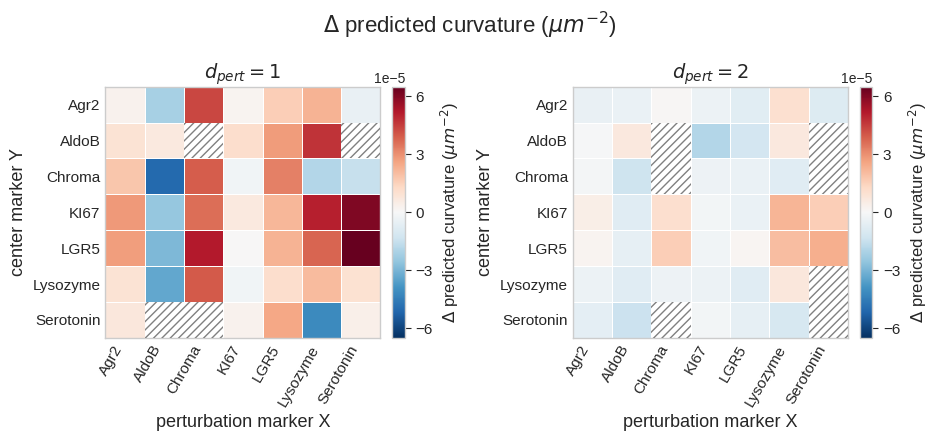

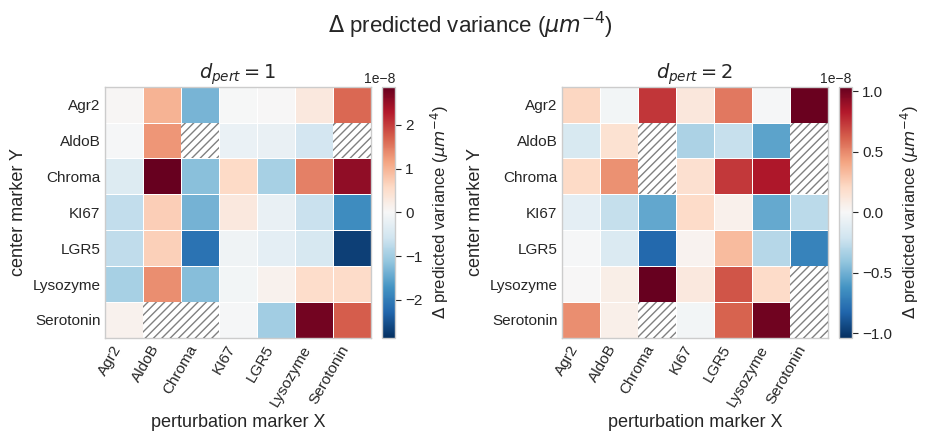

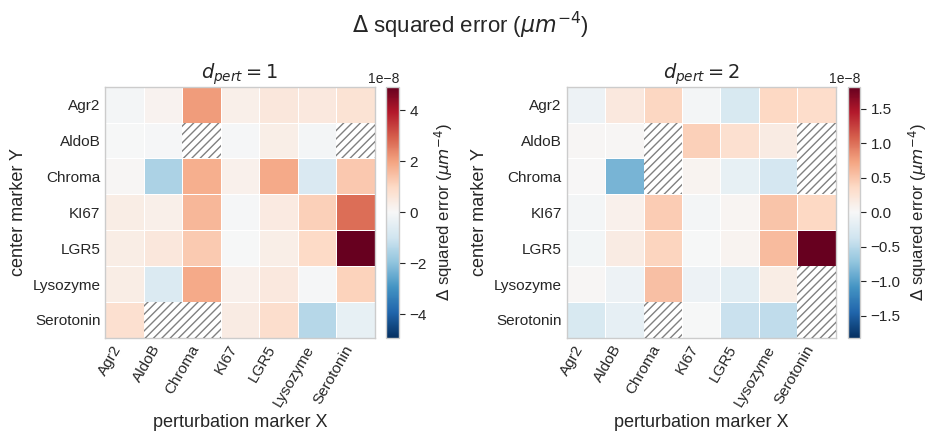

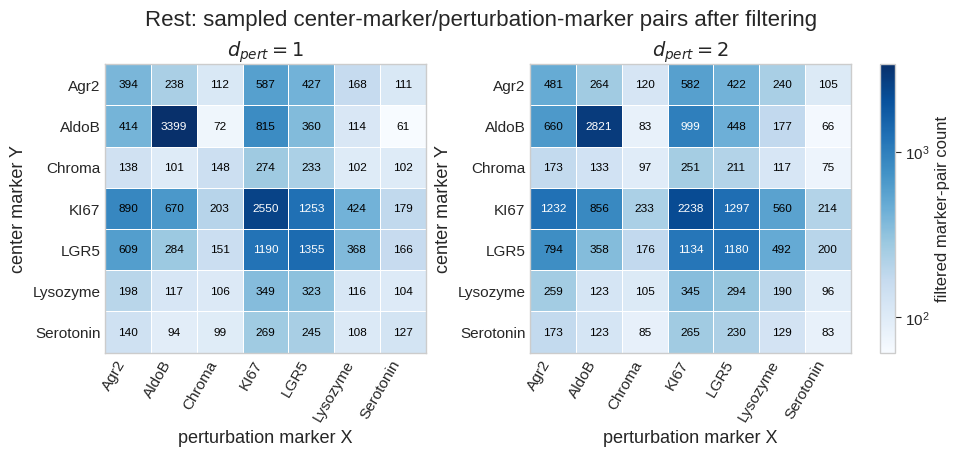

In [75]:
import importlib
from matplotlib.colors import LogNorm
import src.plotting.influence_maps as influence_maps

importlib.reload(influence_maps)
from src.plotting.influence_maps import plot_influence_center_resolved


def heatmap_min_cases_for_run(run):
    if HEATMAP_MIN_CASES is not None:
        return HEATMAP_MIN_CASES
    return int(
        run["settings"]
        .get("perturbation", {})
        .get("heatmap_display_min_cases", 1)
    )


def marker_value_to_index(value, marker_to_index, n_markers):
    if value in marker_to_index:
        return marker_to_index[value]
    try:
        index = int(float(value))
    except (TypeError, ValueError):
        return None
    return index if 0 <= index < n_markers else None


def center_resolved_arrays(summary_df, metric, marker_order):
    hops = sorted(summary_df["hop"].dropna().astype(int).unique())
    marker_to_index = {marker: index for index, marker in enumerate(marker_order)}
    n_markers = len(marker_order)
    values = np.full((len(hops), n_markers, n_markers), np.nan, dtype=float)
    counts = np.zeros((len(hops), n_markers, n_markers), dtype=int)
    hop_to_index = {hop: index for index, hop in enumerate(hops)}

    subset = summary_df[summary_df["metric"] == metric]
    for row in subset.itertuples(index=False):
        if row.center_marker not in marker_to_index:
            continue
        hop_index = hop_to_index.get(int(row.hop))
        source_index = marker_value_to_index(
            row.source_marker, marker_to_index, n_markers
        )
        if hop_index is None or source_index is None:
            continue
        center_index = marker_to_index[row.center_marker]
        values[hop_index, center_index, source_index] = float(row.mean_effect)
        counts[hop_index, center_index, source_index] = int(row.cases)
    return values, counts, hops


def plot_center_resolved_timepoint(metric, timepoint):
    run_summary = center_summary_df[center_summary_df["timepoint"] == timepoint]
    values, counts, hops = center_resolved_arrays(run_summary, metric, marker_names)
    threshold = heatmap_min_cases_for_run(ablation_runs[timepoint])
    limits = CENTER_HEATMAP_LIMITS.get(metric, (None, None))
    ticks = CENTER_HEATMAP_TICKS.get(metric)
    colorbar_label = METRICS[metric]["label"]
    fig, axes = plot_influence_center_resolved(
        values,
        hops,
        marker_names,
        colorbar_label,
        center_zero=True,
        sort_center=False,
        cmap=HEATMAP_CMAP,
        counts=counts,
        min_count=threshold,
        bad_color="white",
        vmin=limits[0],
        vmax=limits[1],
        cbar_ticks=ticks,
        cbar_label=colorbar_label,
    )
    save_figure(
        fig,
        f"center_resolved_{METRICS[metric]['short']}_{safe_filename(timepoint)}",
    )
    plt.show()
    return fig, axes


for metric in METRICS:
    for timepoint in TIMEPOINT_ORDER:
        plot_center_resolved_timepoint(metric, timepoint)


def center_pair_count_tensor(pair_df, marker_order, count_column="filtered_pair_count"):
    hops = sorted(pair_df["hop"].dropna().astype(int).unique())
    marker_to_index = {marker: index for index, marker in enumerate(marker_order)}
    counts = np.zeros((len(hops), len(marker_order), len(marker_order)), dtype=int)
    hop_to_index = {hop: index for index, hop in enumerate(hops)}

    grouped = (
        pair_df.groupby(["hop", "center_marker", "source_marker"], observed=True)[count_column]
        .sum()
        .reset_index()
    )
    for row in grouped.itertuples(index=False):
        if row.center_marker not in marker_to_index:
            continue
        source_index = marker_value_to_index(
            row.source_marker, marker_to_index, len(marker_order)
        )
        if source_index is None:
            continue
        hop_index = hop_to_index[int(row.hop)]
        center_index = marker_to_index[row.center_marker]
        counts[hop_index, center_index, source_index] = int(getattr(row, count_column))
    return counts, hops


def draw_count_heatmap(ax, data, *, cmap, norm, aspect="auto"):
    n_rows, n_cols = np.asarray(data).shape
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad("white")
    masked_data = np.ma.masked_where(np.asarray(data) <= 0, data)
    image = ax.pcolormesh(
        np.arange(n_cols + 1),
        np.arange(n_rows + 1),
        masked_data,
        shading="flat",
        cmap=cmap_obj,
        norm=norm,
        edgecolors="white",
        linewidth=0.6,
        antialiased=False,
        snap=True,
    )
    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_aspect(aspect)
    ax.grid(False)
    return image


def annotate_count_heatmap(ax, data, image, *, fontsize=8.5):
    norm = image.norm
    cmap = image.cmap
    for row_index in range(data.shape[0]):
        for column_index in range(data.shape[1]):
            value = int(data[row_index, column_index])
            rgba = (1, 1, 1, 1) if value <= 0 else cmap(norm(value))
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if luminance < 0.45 else "black"
            ax.text(
                column_index + 0.5,
                row_index + 0.5,
                f"{value}",
                ha="center",
                va="center",
                fontsize=fontsize,
                color=text_color,
                zorder=4,
            )


def plot_center_pair_sampling_counts(timepoint):
    pair_df = center_pair_counts_after_filtering_df[
        center_pair_counts_after_filtering_df["timepoint"] == timepoint
    ]
    counts, hops = center_pair_count_tensor(pair_df, marker_names)
    positive_counts = counts[counts > 0]
    vmin = max(1, int(positive_counts.min())) if positive_counts.size else 1
    vmax = max(vmin, int(counts.max()))
    norm = LogNorm(vmin=vmin, vmax=vmax)
    fig, axes = plt.subplots(
        1,
        len(hops),
        figsize=(0.50 * len(marker_names) * len(hops) + 2.5, 0.35 * len(marker_names) + 2),
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes[0]
    image = None
    for hop_index, hop in enumerate(hops):
        ax = axes[hop_index]
        data = counts[hop_index]
        image = draw_count_heatmap(
            ax,
            data,
            aspect="auto",
            cmap=PAIR_COUNT_HEATMAP_CMAP,
            norm=norm,
        )
        annotate_count_heatmap(ax, data, image)
        ax.set_title(rf"$d_{{pert}} = {hop}$", fontsize=14)
        ax.set_xlabel("perturbation marker X", fontsize=13)
        ax.set_ylabel("center marker Y", fontsize=13)
        ax.set_xticks(np.arange(len(marker_names)) + 0.5)
        ax.set_xticklabels(marker_names, rotation=60, ha="right", fontsize=11)
        ax.set_yticks(np.arange(len(marker_names)) + 0.5)
        ax.set_yticklabels(marker_names, fontsize=11)

    cbar = fig.colorbar(image, ax=list(axes), fraction=0.046, pad=0.04)
    cbar.set_label("filtered marker-pair count", fontsize=12)
    cbar.ax.tick_params(labelsize=11, length=4, width=0.8, direction="out")
    fig.suptitle(
        f"{timepoint}: sampled center-marker/perturbation-marker pairs after filtering",
        fontsize=16,
    )
    save_figure(fig, f"center_pair_sampling_counts_{safe_filename(timepoint)}")
    plt.show()
    return fig, axes


for timepoint in TIMEPOINT_ORDER:
    plot_center_pair_sampling_counts(timepoint)


## Population Ablation Curves


In [ ]:
POPULATION_ABLATION_METRIC = "delta_mu"
POPULATION_CURVATURE_ESTIMANDS = {
    "raw": {
        "value": "conditional_effect",
        "sem": "conditional_sem",
        "label": rf"Raw $\Delta \mu$ ({CURVATURE_UNIT_LABEL})",
        "filename": "conditional_effect_curvature",
        "title": "Raw curvature difference",
    },
    "adjusted": {
        "value": "prevalence_weighted_effect",
        "sem": "prevalence_weighted_sem",
        "label": rf"Abundance-adjusted $\Delta \mu$ ({CURVATURE_UNIT_LABEL})",
        "filename": "abundance_adjusted_effect_curvature",
        "title": "Abundance-adjusted curvature difference",
    },
}
marker_colors = {
    "Chroma": "#F392E3",
    "Serotonin": "#FE2BCD",
    "Glucagon": "#973BD8",
    "Agr 2": "#3EC1D9",
    "Mucin": "#71DAA8",
    "Lysozyme": "#024BFF",
    "Lgr5": "#FFB431",
    "AldoB": "#FF3E23",
    "KI67": "#A6A6A6",
    "NONE": "#666666",
}
MARKER_COLOR_ALIASES = {
    "Agr2": "Agr 2",
    "Agr 2": "Agr 2",
    "LGR5": "Lgr5",
    "Lgr5": "Lgr5",
    "Mucin 2": "Mucin",
    "Mucin": "Mucin",
    "Ki67": "KI67",
    "KI67": "KI67",
    "no_marker": "NONE",
    "No markers": "NONE",
    "NONE": "NONE",
}
TIMEPOINT_LINESTYLES = dict(zip(
    TIMEPOINT_ORDER,
    ["-", "--", ":", "-."][:len(TIMEPOINT_ORDER)],
))


def marker_color(marker):
    key = MARKER_COLOR_ALIASES.get(str(marker), str(marker))
    return marker_colors.get(key, "#4a4a4a")


def population_marker_column(df):
    if "marker" in df.columns:
        return "marker"
    if "source_marker_name" in df.columns:
        return "source_marker_name"
    return "source_marker"


def population_curvature_table(estimand_key):
    if population_summary_df.empty:
        return pd.DataFrame(), None, []
    estimand = POPULATION_CURVATURE_ESTIMANDS[estimand_key]
    value_column = estimand["value"]
    sem_column = estimand["sem"]
    required_columns = {"timepoint", "hop", "metric", value_column, sem_column}
    missing_columns = sorted(required_columns - set(population_summary_df.columns))
    if missing_columns:
        print(
            "Population summary table is missing columns "
            f"{missing_columns}; skipping {estimand_key} population curvature curves."
        )
        return pd.DataFrame(), None, []

    marker_column = population_marker_column(population_summary_df)
    curves = population_summary_df.loc[
        population_summary_df["metric"].eq(POPULATION_ABLATION_METRIC)
    ].copy()
    if curves.empty:
        print("No population rows found for delta_mu.")
        return pd.DataFrame(), marker_column, []

    curves[marker_column] = curves[marker_column].astype(str)
    curves["hop"] = pd.to_numeric(curves["hop"], errors="coerce")
    curves[value_column] = pd.to_numeric(curves[value_column], errors="coerce")
    curves[sem_column] = pd.to_numeric(curves[sem_column], errors="coerce")
    curves = curves.dropna(subset=["hop", value_column])
    markers_present = list(dict.fromkeys(curves[marker_column].dropna().astype(str)))
    ordered_markers = [marker for marker in marker_names if marker in markers_present]
    ordered_markers.extend(marker for marker in markers_present if marker not in ordered_markers)
    return curves, marker_column, ordered_markers


def symmetric_population_ylim(curves, estimand_key):
    estimand = POPULATION_CURVATURE_ESTIMANDS[estimand_key]
    value_column = estimand["value"]
    sem_column = estimand["sem"]
    if curves.empty:
        return None
    y = curves[value_column].to_numpy(float)
    sem = curves[sem_column].fillna(0.0).to_numpy(float)
    finite = np.isfinite(y) & np.isfinite(sem)
    if not np.any(finite):
        return None
    max_abs = np.nanmax(np.abs(np.concatenate([y[finite] - sem[finite], y[finite] + sem[finite], [0.0]])))
    if not np.isfinite(max_abs) or max_abs <= 0:
        max_abs = 1.0
    return (-1.08 * max_abs, 1.08 * max_abs)


def draw_population_curve(
    ax,
    curve,
    *,
    value_column,
    sem_column,
    color,
    label=None,
    linestyle="-",
    marker="o",
    alpha=0.16,
):
    curve = curve.sort_values("hop")
    x = curve["hop"].to_numpy(float)
    y = curve[value_column].to_numpy(float)
    sem = curve[sem_column].fillna(0.0).to_numpy(float)
    line, = ax.plot(
        x,
        y,
        marker=marker,
        linewidth=1.8,
        markersize=4.0,
        color=color,
        linestyle=linestyle,
        label=label,
    )
    ax.fill_between(
        x,
        y - sem,
        y + sem,
        color=color,
        alpha=alpha,
        linewidth=0,
    )
    return line


def plot_population_curvature_panels(estimand_key):
    curves, marker_column, ordered_markers = population_curvature_table(estimand_key)
    if curves.empty:
        print("No population_effect_summary.csv tables found for the selected ablation runs; skipping population curves.")
        return None, None, None

    estimand = POPULATION_CURVATURE_ESTIMANDS[estimand_key]
    value_column = estimand["value"]
    sem_column = estimand["sem"]
    y_limits = symmetric_population_ylim(curves, estimand_key)
    n_markers = len(ordered_markers)
    n_columns = POPULATION_PANEL_COLUMNS
    n_rows = int(np.ceil(n_markers / n_columns))
    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(1.41 * n_columns, 2.58 * n_rows),
        sharex=True,
        sharey=True,
        constrained_layout=True,
        squeeze=False,
    )
    axes_flat = axes.ravel()
    handles = []
    labels = []
    for marker_index, marker in enumerate(ordered_markers):
        ax = axes_flat[marker_index]
        marker_df = curves.loc[curves[marker_column].eq(marker)]
        for timepoint in TIMEPOINT_ORDER:
            curve = marker_df.loc[marker_df["timepoint"].eq(timepoint)].copy()
            if curve.empty:
                continue
            label = timepoint if len(TIMEPOINT_ORDER) > 1 else marker
            color = marker_color(marker)
            line = draw_population_curve(
                ax,
                curve,
                value_column=value_column,
                sem_column=sem_column,
                color=color,
                label=label,
                linestyle=TIMEPOINT_LINESTYLES.get(timepoint, "-"),
            )
            if label not in labels:
                handles.append(line)
                labels.append(label)
        ax.axhline(0, color="0.35", linewidth=0.8, linestyle="--", alpha=0.65)
        if y_limits is not None:
            ax.set_ylim(*y_limits)
        ax.set_title(marker, fontsize=10.5, pad=3, color=marker_color(marker))
        ax.tick_params(axis="both", labelsize=8.5)
        ax.set_xticks(sorted(curves["hop"].dropna().astype(int).unique()))
        if marker_index % n_columns == 0:
            ax.set_ylabel(estimand["label"], fontsize=9.5)
        if marker_index // n_columns == n_rows - 1:
            ax.set_xlabel("perturbation distance (graph hops)", fontsize=9.5)

    for empty_ax in axes_flat[n_markers:]:
        empty_ax.axis("off")
    if len(TIMEPOINT_ORDER) > 1 and handles:
        if n_markers < len(axes_flat):
            legend_ax = axes_flat[n_markers]
            legend_ax.axis("off")
            legend_ax.legend(
                handles,
                labels,
                loc="center",
                frameon=False,
                fontsize=8.5,
                title="run",
                title_fontsize=8.5,
            )
        else:
            fig.legend(
                handles,
                labels,
                loc="lower center",
                ncol=max(1, len(handles)),
                frameon=False,
                fontsize=8.5,
                title="run",
                title_fontsize=8.5,
            )
    fig.suptitle(f"Population ablation: {estimand['title']}", fontsize=12)
    save_figure(fig, f"population_ablation_{estimand['filename']}")
    plt.show()
    return fig, axes, y_limits


def plot_population_curvature_all_markers(y_limits_by_estimand=None):
    y_limits_by_estimand = y_limits_by_estimand or {}
    n_panels = len(POPULATION_CURVATURE_ESTIMANDS)
    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(2.07 * n_panels, 3.18),
        sharex=True,
        constrained_layout=True,
        squeeze=False,
    )
    axes_flat = axes.ravel()
    legend_handles = []
    legend_labels = []

    for ax, (estimand_key, estimand) in zip(axes_flat, POPULATION_CURVATURE_ESTIMANDS.items()):
        curves, marker_column, ordered_markers = population_curvature_table(estimand_key)
        if curves.empty:
            ax.axis("off")
            continue
        value_column = estimand["value"]
        sem_column = estimand["sem"]
        y_limits = y_limits_by_estimand.get(estimand_key) or symmetric_population_ylim(curves, estimand_key)
        for timepoint in TIMEPOINT_ORDER:
            timepoint_df = curves.loc[curves["timepoint"].eq(timepoint)]
            for marker in ordered_markers:
                curve = timepoint_df.loc[timepoint_df[marker_column].eq(marker)].copy()
                if curve.empty:
                    continue
                color = marker_color(marker)
                label = marker if len(TIMEPOINT_ORDER) == 1 else f"{marker} ({timepoint})"
                line = draw_population_curve(
                    ax,
                    curve,
                    value_column=value_column,
                    sem_column=sem_column,
                    color=color,
                    label=label,
                    marker="o",
                    linestyle=TIMEPOINT_LINESTYLES.get(timepoint, "-"),
                    alpha=0.12,
                )
                if label not in legend_labels:
                    legend_handles.append(line)
                    legend_labels.append(label)
        ax.axhline(0, color="0.35", linewidth=0.8, linestyle="--", alpha=0.65)
        if y_limits is not None:
            ax.set_ylim(*y_limits)
        ax.set_xticks(sorted(curves["hop"].dropna().astype(int).unique()))
        ax.set_xlabel("perturbation distance (graph hops)", fontsize=9.5)
        ax.set_title(estimand["title"], fontsize=10.5, pad=3)
        ax.set_ylabel(estimand["label"], fontsize=9.5)
        ax.tick_params(axis="both", labelsize=8.5)
        ax.grid(alpha=0.25)

    fig.legend(
        legend_handles,
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        fontsize=8.0,
    )
    fig.suptitle("Population ablation: all markers", fontsize=12)
    save_figure(fig, "population_ablation_curvature_all_markers_raw_and_adjusted")
    plt.show()
    return fig, axes


population_curvature_figures = {}
population_curvature_ylims = {}
for estimand_key in POPULATION_CURVATURE_ESTIMANDS:
    fig, axes, y_limits = plot_population_curvature_panels(estimand_key)
    population_curvature_figures[estimand_key] = (fig, axes)
    population_curvature_ylims[estimand_key] = y_limits
plot_population_curvature_all_markers(population_curvature_ylims)


## Lineage Removal / Marker Isolation

This section loads saved outputs from `lineage_removal.ipynb` and recreates the region-wise MSE figures from the stored summary tables. It does not load graph data or trained models.

In [76]:
REQUIRED_LINEAGE_TABLES = {
    "mse": "mse_summary_across_organoids.csv",
    "baseline": "global_baseline_summary_across_organoids.csv",
    "organoid_mse": "organoid_level_mse.csv",
    "baseline_organoid_mse": "global_baseline_organoid_mse.csv",
    "zero_counts": "marker_zero_counts.csv",
    "training": "training_summary.csv",
}


def is_complete_lineage_run(run_dir):
    run_dir = Path(run_dir)
    try:
        settings = load_json(result_settings_path(run_dir))
    except (FileNotFoundError, json.JSONDecodeError):
        return False
    tables_dir = run_dir / "tables"
    return all(
        (tables_dir / filename).exists()
        for filename in REQUIRED_LINEAGE_TABLES.values()
    )


def discover_latest_lineage_run():
    candidates = []
    if not LINEAGE_RESULTS_ROOT.exists():
        raise FileNotFoundError(LINEAGE_RESULTS_ROOT)
    for run_dir in LINEAGE_RESULTS_ROOT.iterdir():
        if not run_dir.is_dir() or not is_complete_lineage_run(run_dir):
            continue
        settings = load_json(result_settings_path(run_dir))
        split_mode = settings.get("split", {}).get("analysis_mode")
        analysis_variant = settings.get("analysis_variant")
        if LINEAGE_REQUIRE_FOLDED and split_mode != "folded":
            continue
        if (
            LINEAGE_ANALYSIS_VARIANT is not None
            and analysis_variant != LINEAGE_ANALYSIS_VARIANT
        ):
            continue
        candidates.append(run_dir)
    if not candidates:
        raise FileNotFoundError("No complete lineage_removal run found.")
    return max(candidates, key=lambda path: path.stat().st_mtime)


def load_lineage_run(run_dir):
    run_dir = Path(run_dir).expanduser().resolve()
    settings_path = result_settings_path(run_dir)
    settings = load_json(settings_path)
    tables = {
        key: pd.read_csv(run_dir / "tables" / filename)
        for key, filename in REQUIRED_LINEAGE_TABLES.items()
    }
    return {
        "run_dir": run_dir,
        "settings_path": settings_path,
        "settings": settings,
        "tables": tables,
    }


lineage_run_dir = (
    discover_latest_lineage_run()
    if LINEAGE_RUN_DIR is None
    else Path(LINEAGE_RUN_DIR).expanduser().resolve()
)
lineage_run = load_lineage_run(lineage_run_dir)
lineage_settings = lineage_run["settings"]
lineage_mse_df = lineage_run["tables"]["mse"].copy()
lineage_baseline_df = lineage_run["tables"]["baseline"].copy()
lineage_organoid_mse_df = lineage_run["tables"]["organoid_mse"].copy()
lineage_baseline_organoid_mse_df = lineage_run["tables"]["baseline_organoid_mse"].copy()
lineage_zero_counts_df = lineage_run["tables"]["zero_counts"].copy()
lineage_training_df = lineage_run["tables"]["training"].copy()

lineage_mse_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_baseline_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_organoid_mse_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_baseline_organoid_mse_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_zero_counts_df.insert(0, "run_dir", str(lineage_run["run_dir"]))
lineage_training_df.insert(0, "run_dir", str(lineage_run["run_dir"]))


def scale_numeric_columns(df, columns, factor):
    out = df.copy()
    for column in columns:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce") * factor
    return out


def scale_all_mse_columns(df):
    mse_columns = [column for column in df.columns if "mse" in column.lower()]
    return scale_numeric_columns(df, mse_columns, CURVATURE_SQUARED_TO_PHYSICAL_FACTOR)


lineage_mse_df = scale_numeric_columns(
    lineage_mse_df,
    ["mean_mse", "std_mse", "sem_mse"],
    CURVATURE_SQUARED_TO_PHYSICAL_FACTOR,
)
lineage_baseline_df = scale_numeric_columns(
    lineage_baseline_df,
    ["mean_mse", "std_mse", "sem_mse"],
    CURVATURE_SQUARED_TO_PHYSICAL_FACTOR,
)
lineage_organoid_mse_df = scale_numeric_columns(
    lineage_organoid_mse_df,
    ["mse"],
    CURVATURE_SQUARED_TO_PHYSICAL_FACTOR,
)
lineage_baseline_organoid_mse_df = scale_numeric_columns(
    lineage_baseline_organoid_mse_df,
    ["mse"],
    CURVATURE_SQUARED_TO_PHYSICAL_FACTOR,
)
lineage_training_df = scale_all_mse_columns(lineage_training_df)

lineage_mse_df.to_csv(
    TABLES_DIR / "lineage_mse_summary_across_organoids.csv", index=False
)
lineage_baseline_df.to_csv(
    TABLES_DIR / "lineage_global_baseline_summary_across_organoids.csv",
    index=False,
)
lineage_organoid_mse_df.to_csv(
    TABLES_DIR / "lineage_organoid_level_mse.csv", index=False
)
lineage_baseline_organoid_mse_df.to_csv(
    TABLES_DIR / "lineage_global_baseline_organoid_mse.csv", index=False
)
lineage_run_summary_df = pd.DataFrame([{
    "run_dir": str(lineage_run["run_dir"]),
    "analysis_variant": lineage_settings.get("analysis_variant"),
    "analysis_mode": lineage_settings.get("split", {}).get("analysis_mode"),
    "timepoint_filter_mode": lineage_settings.get("filtering", {}).get(
        "timepoint_filter_mode"
    ),
    "model_depths": repr(lineage_settings.get("model", {}).get("depths")),
    "n_removal_sets": len(lineage_settings.get("removal_sets", [])),
    "n_graphs_after_filtering": lineage_settings.get("filtering", {}).get(
        "n_graphs_after_filtering"
    ),
}])
lineage_run_summary_df.to_csv(
    TABLES_DIR / "lineage_run_summary.csv", index=False
)
display(lineage_run_summary_df)
display(lineage_mse_df.head(12))

,run_dir,analysis_variant,analysis_mode,timepoint_filter_mode,model_depths,n_removal_sets,n_graphs_after_filtering
0,/home/fmoller/Projects/LearningOrganoids/Graph...,marker_isolation_plus_targeted_removal,folded,rest,"[0, 1, 2, 3, 4]",11,811


,run_dir,removal_key,removal_label,train_eval_key,train_eval_label,depth,region,mean_mse,std_mse,sem_mse,n_organoids,n_nodes
0,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lgr5,LGR5 only,orig_orig,orig/orig,0,full,2.530115e-07,1.999947e-07,7.022763e-09,811.0,401152.0
1,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lgr5,LGR5 only,orig_orig,orig/orig,0,crypt,4.996875e-07,4.707194e-07,1.696355e-08,770.0,88360.0
2,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lgr5,LGR5 only,orig_orig,orig/orig,0,neck,4.355587e-07,5.446041e-07,1.962617e-08,770.0,87410.0
3,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lgr5,LGR5 only,orig_orig,orig/orig,0,villus,1.533068e-07,1.532116e-07,5.423631e-09,798.0,225382.0
4,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lysozyme_Agr2,Lysozyme + Agr2 only,orig_orig,orig/orig,0,full,2.530115e-07,1.999947e-07,7.022763e-09,811.0,401152.0
5,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lysozyme_Agr2,Lysozyme + Agr2 only,orig_orig,orig/orig,0,crypt,4.996875e-07,4.707194e-07,1.696355e-08,770.0,88360.0
6,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lysozyme_Agr2,Lysozyme + Agr2 only,orig_orig,orig/orig,0,neck,4.355587e-07,5.446041e-07,1.962617e-08,770.0,87410.0
7,/home/fmoller/Projects/LearningOrganoids/Graph...,only_lysozyme_Agr2,Lysozyme + Agr2 only,orig_orig,orig/orig,0,villus,1.533068e-07,1.532116e-07,5.423631e-09,798.0,225382.0
8,/home/fmoller/Projects/LearningOrganoids/Graph...,only_sero_chroma,Serotonin + Chroma only,orig_orig,orig/orig,0,full,2.530115e-07,1.999947e-07,7.022763e-09,811.0,401152.0
9,/home/fmoller/Projects/LearningOrganoids/Graph...,only_sero_chroma,Serotonin + Chroma only,orig_orig,orig/orig,0,crypt,4.996875e-07,4.707194e-07,1.696355e-08,770.0,88360.0


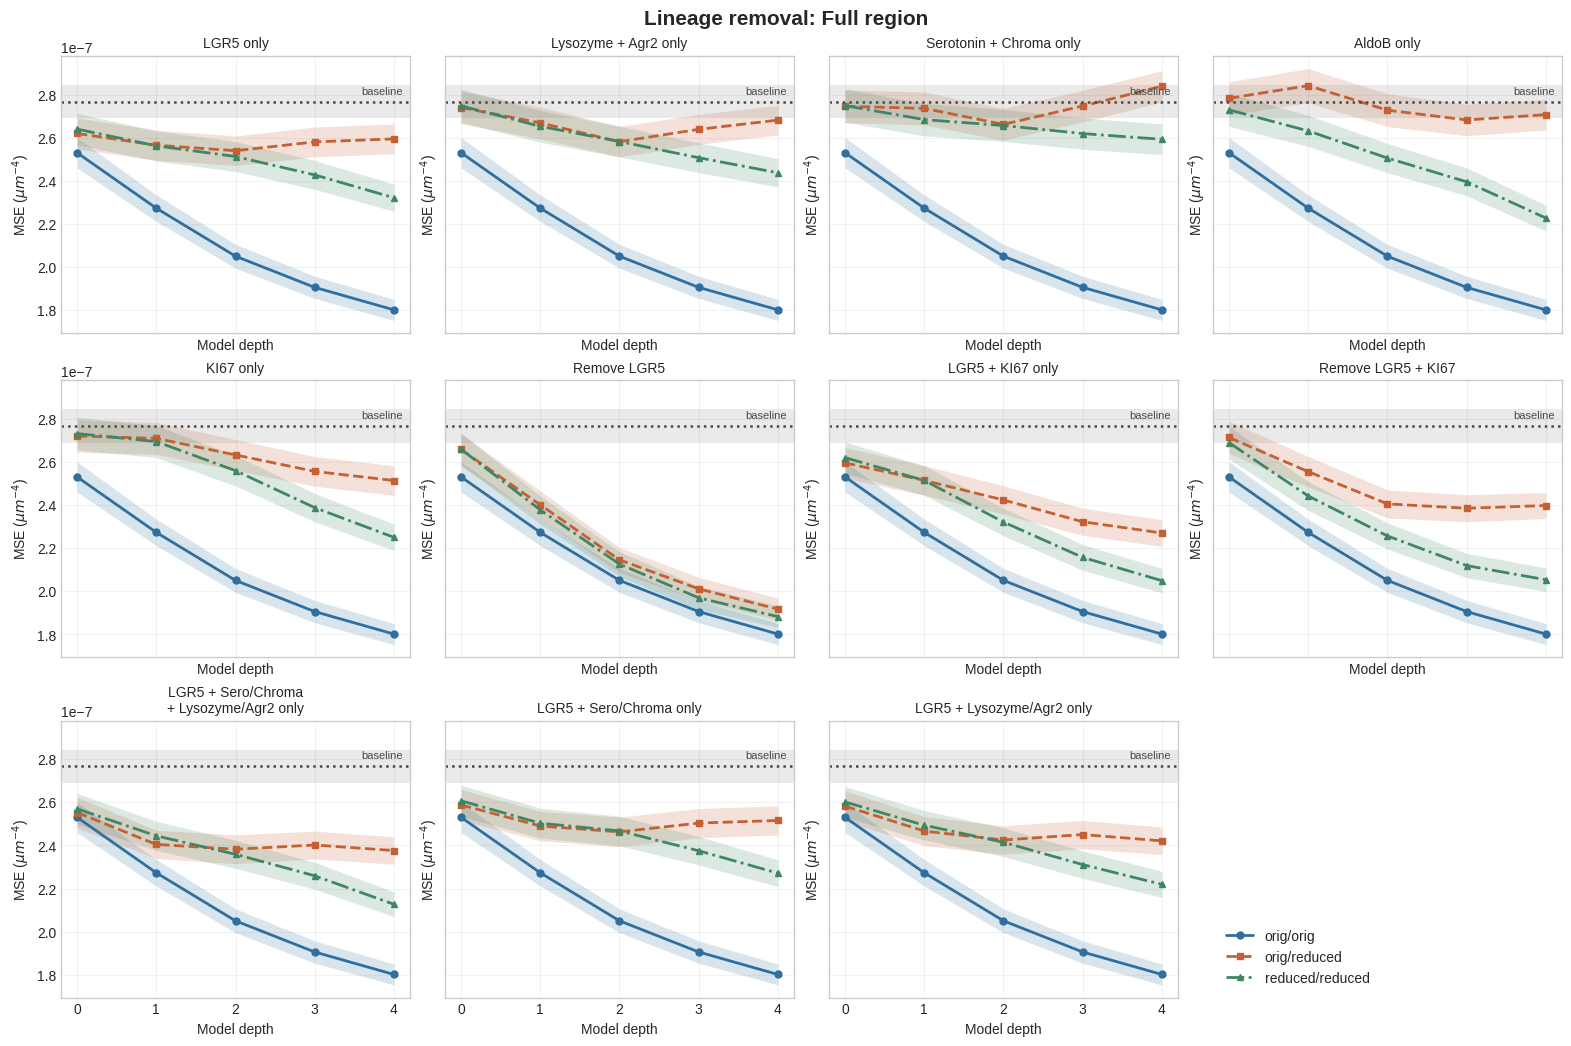

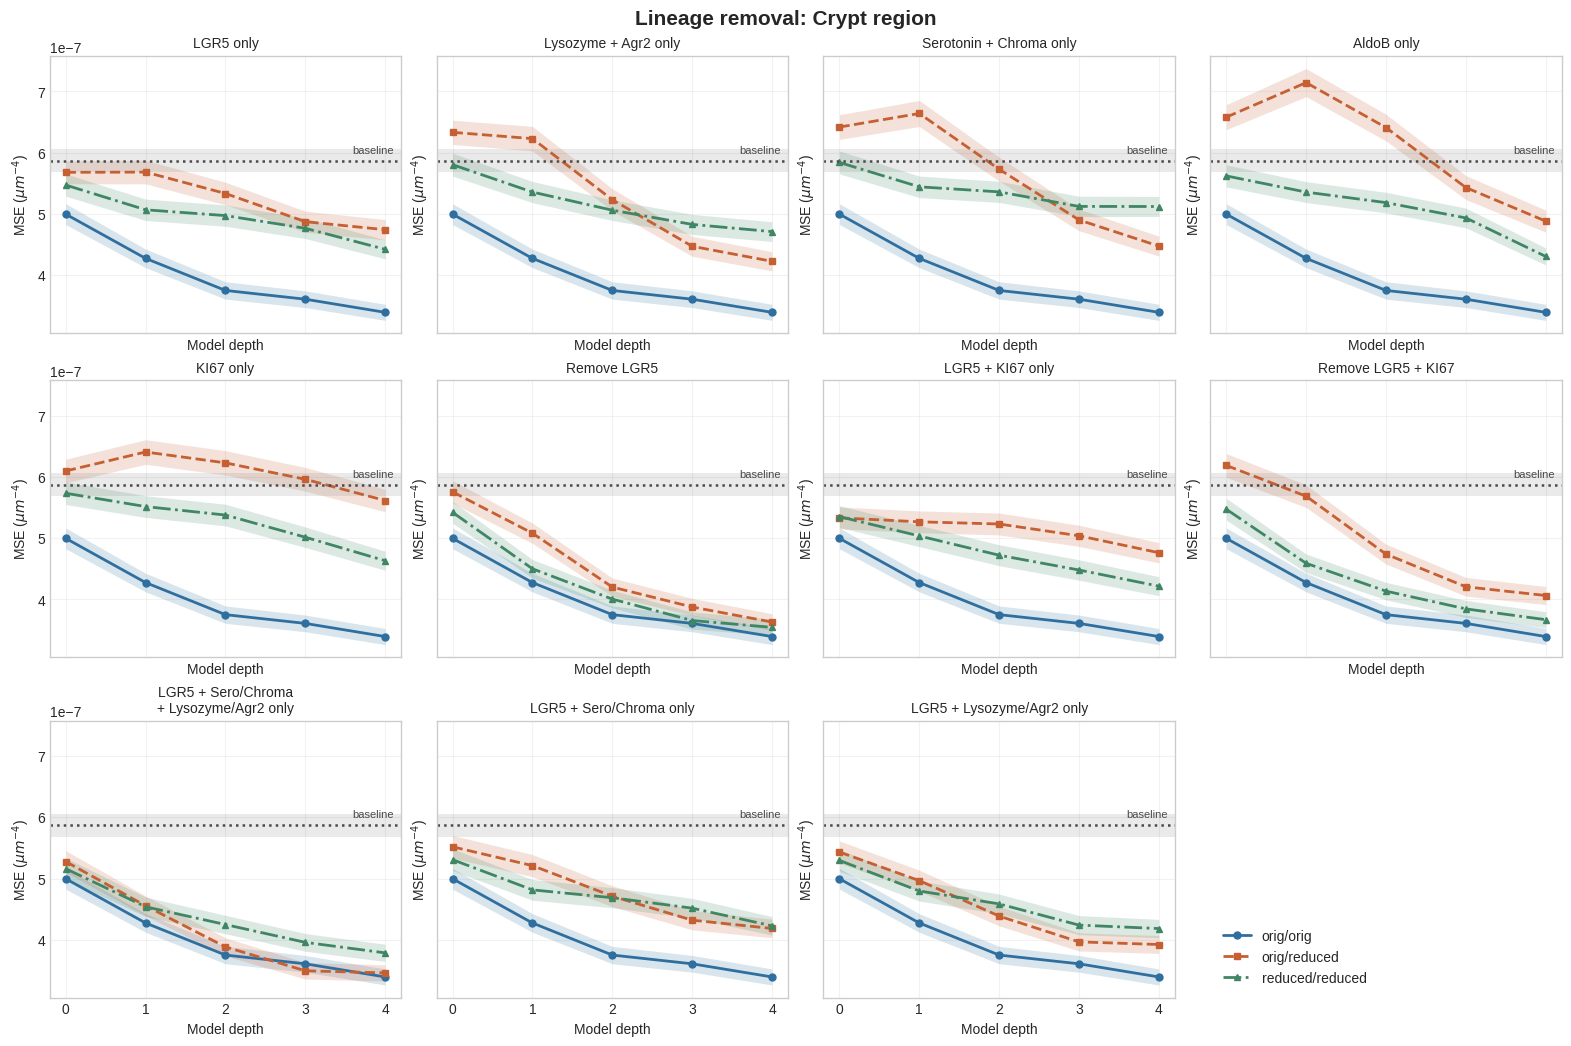

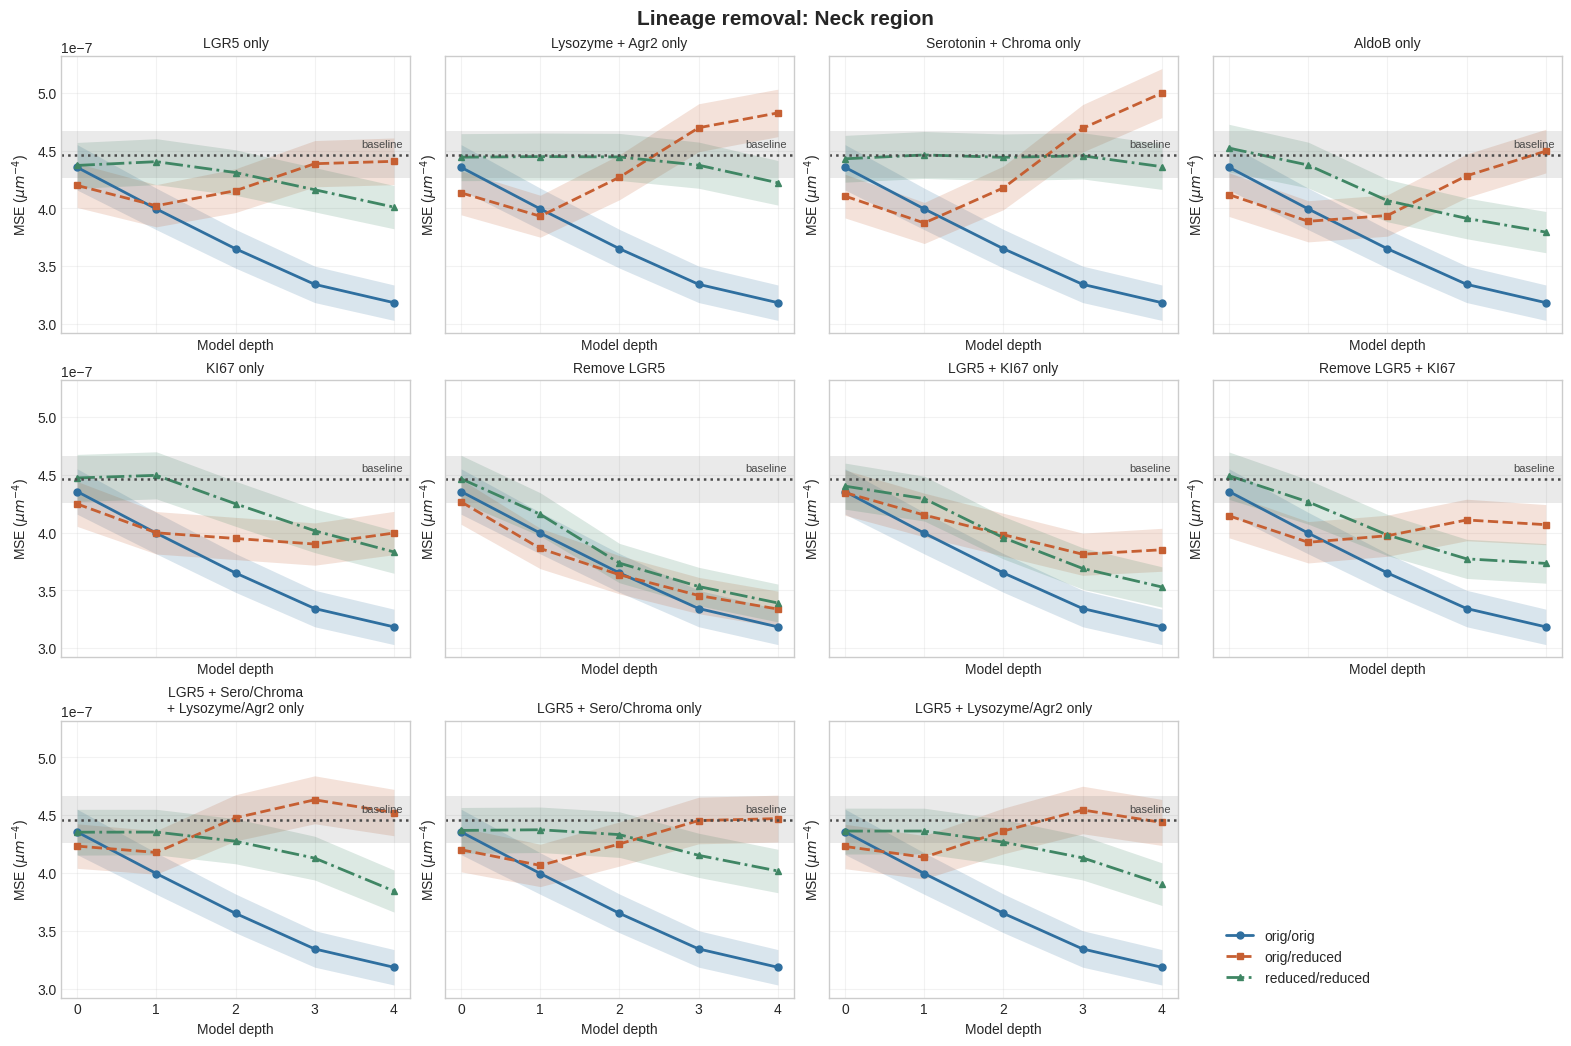

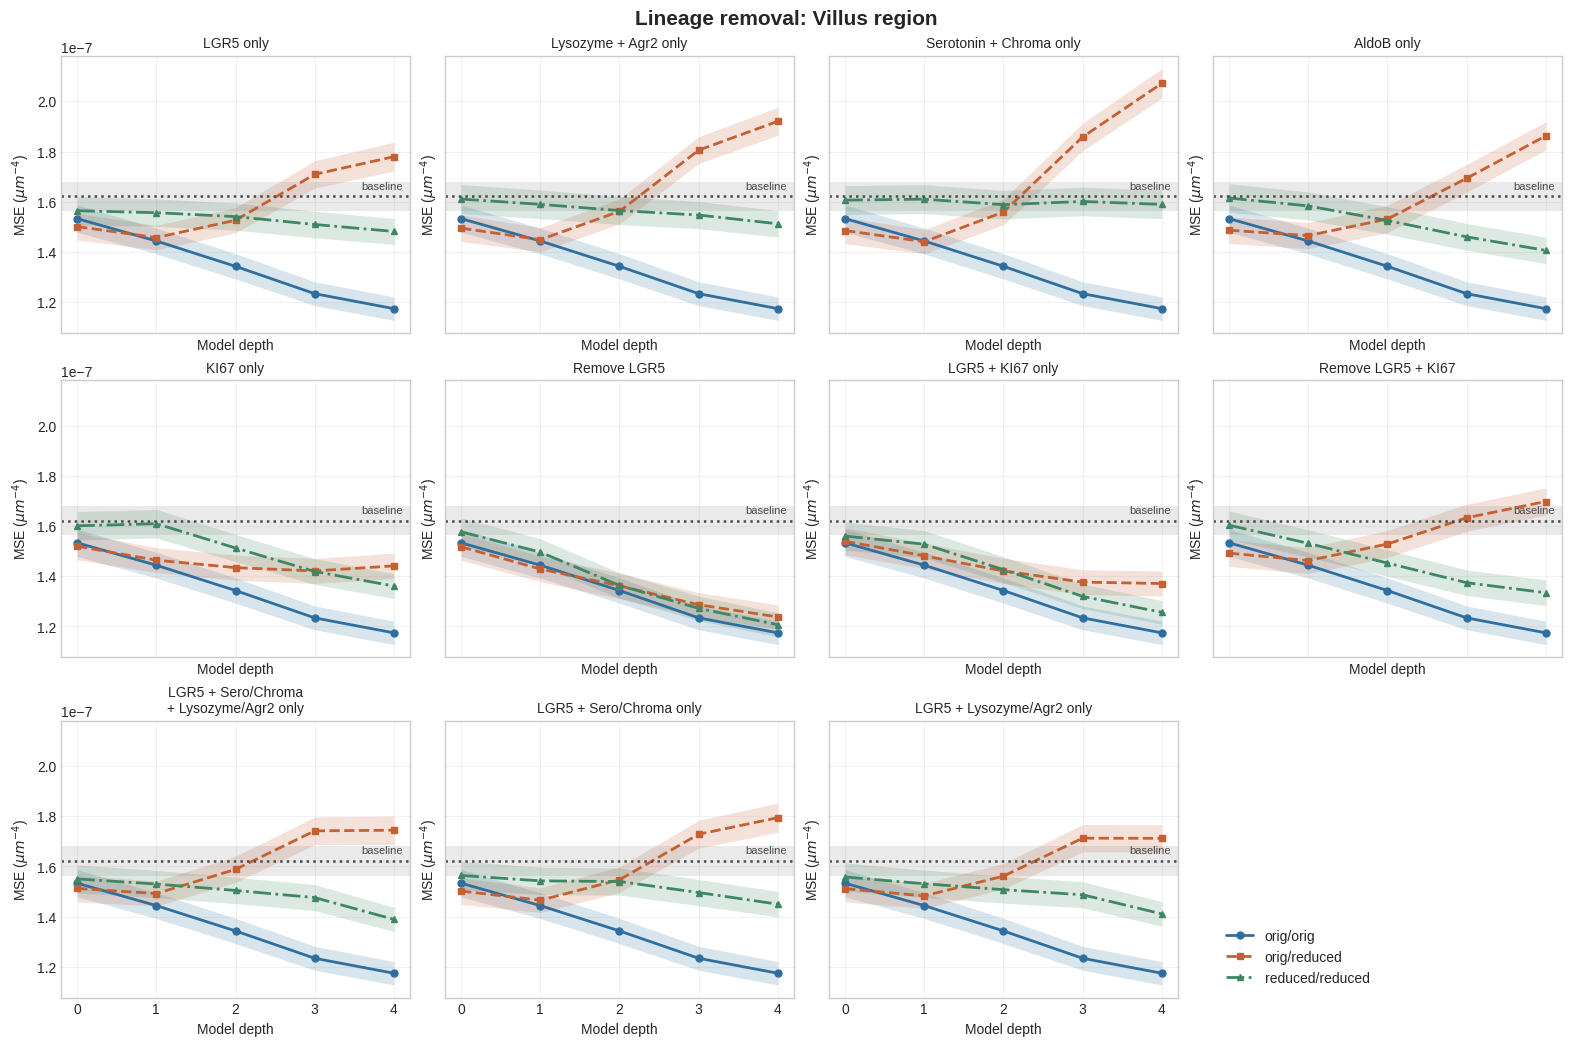

In [77]:
LINEAGE_COMBO_ORDER = ["orig_orig", "orig_reduced", "reduced_reduced"]
LINEAGE_COMBO_STYLE = {
    "orig_orig": {
        "label": "orig/orig",
        "color": "#2f6f9f",
        "marker": "o",
        "linestyle": "-",
    },
    "orig_reduced": {
        "label": "orig/reduced",
        "color": "#c65f32",
        "marker": "s",
        "linestyle": "--",
    },
    "reduced_reduced": {
        "label": "reduced/reduced",
        "color": "#3f8664",
        "marker": "^",
        "linestyle": "-.",
    },
}


def lineage_removal_sets_from_results():
    settings_sets = lineage_settings.get("removal_sets") or []
    if settings_sets:
        return [
            {
                "key": spec.get("key"),
                "label": spec.get("label", spec.get("key")),
                "markers": spec.get("markers"),
                "keep_markers": spec.get("keep_markers"),
            }
            for spec in settings_sets
        ]
    ordered = (
        lineage_mse_df[["removal_key", "removal_label"]]
        .drop_duplicates()
        .rename(columns={"removal_key": "key", "removal_label": "label"})
    )
    return ordered.to_dict(orient="records")


LINEAGE_REMOVAL_SETS = lineage_removal_sets_from_results()
LINEAGE_MODEL_DEPTHS = sorted(
    lineage_mse_df["depth"].dropna().astype(int).unique().tolist()
)
LINEAGE_REGION_ORDER_EFFECTIVE = [
    region
    for region in LINEAGE_REGION_ORDER
    if region in set(lineage_mse_df["region"])
]
if not LINEAGE_REGION_ORDER_EFFECTIVE:
    LINEAGE_REGION_ORDER_EFFECTIVE = sorted(lineage_mse_df["region"].unique())


def label_horizontal_baseline(ax, y, label="baseline", *, fontsize=8):
    ax.annotate(
        label,
        xy=(0.98, y),
        xycoords=ax.get_yaxis_transform(),
        xytext=(0, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=fontsize,
        color="#4a4a4a",
    )


def plot_lineage_region_mse(region):
    region_df = lineage_mse_df[lineage_mse_df["region"] == region]
    baseline_row = lineage_baseline_df[
        lineage_baseline_df["region"] == region
    ]
    if baseline_row.empty:
        raise ValueError(f"No global baseline result for region {region!r}.")
    baseline_mean = float(baseline_row.iloc[0]["mean_mse"])
    baseline_sem = float(baseline_row.iloc[0]["sem_mse"])

    n_panels = len(LINEAGE_REMOVAL_SETS)
    n_cols = 4
    n_rows = int(np.ceil(max(n_panels, 1) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.9 * n_cols, 3.45 * n_rows),
        sharex=True,
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )
    axes_flat = axes.ravel()
    legend_handles = []
    legend_labels = []

    for panel_idx, (ax, spec) in enumerate(
        zip(axes_flat, LINEAGE_REMOVAL_SETS)
    ):
        panel = region_df[region_df["removal_key"] == spec["key"]]
        for combo in LINEAGE_COMBO_ORDER:
            style = LINEAGE_COMBO_STYLE[combo]
            curve = (
                panel[panel["train_eval_key"] == combo]
                .sort_values("depth")
            )
            if curve.empty:
                continue
            x = curve["depth"].to_numpy(dtype=float)
            y = curve["mean_mse"].to_numpy(dtype=float)
            sem = curve["sem_mse"].to_numpy(dtype=float)
            line, = ax.plot(
                x,
                y,
                color=style["color"],
                marker=style["marker"],
                linestyle=style["linestyle"],
                linewidth=2.0,
                markersize=5,
                label=style["label"],
            )
            valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(sem)
            if np.any(valid):
                ax.fill_between(
                    x[valid],
                    y[valid] - sem[valid],
                    y[valid] + sem[valid],
                    color=style["color"],
                    alpha=0.18,
                    linewidth=0,
                )
            if panel_idx == 0:
                legend_handles.append(line)
                legend_labels.append(style["label"])

        ax.axhline(
            baseline_mean,
            color="#4a4a4a",
            linestyle=":",
            linewidth=1.8,
        )
        ax.axhspan(
            baseline_mean - baseline_sem,
            baseline_mean + baseline_sem,
            color="#6b6b6b",
            alpha=0.14,
            linewidth=0,
        )
        label_horizontal_baseline(ax, baseline_mean)
        ax.set_title(spec["label"], fontsize=10)
        ax.set_xticks(LINEAGE_MODEL_DEPTHS)
        ax.set_xlabel("Model depth")
        ax.set_ylabel(f"MSE ({MSE_UNIT_LABEL})")
        ax.grid(alpha=0.25)

    unused_axes = axes_flat[n_panels:]
    if len(unused_axes):
        legend_ax = unused_axes[0]
        legend_ax.set_axis_off()
        legend_ax.legend(
            legend_handles,
            legend_labels,
            loc="lower left",
            frameon=False,
        )
        for ax in unused_axes[1:]:
            ax.set_visible(False)
    else:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="lower left",
            bbox_to_anchor=(0.01, 0.01),
            ncol=min(4, len(legend_handles)),
            frameon=False,
        )

    fig.suptitle(
        f"Lineage removal: {region.capitalize()} region",
        fontsize=15,
        fontweight="bold",
    )
    save_figure(fig, f"lineage_removal_mse_{region}")
    plt.show()
    return fig, axes


lineage_region_figures = {
    region: plot_lineage_region_mse(region)
    for region in LINEAGE_REGION_ORDER_EFFECTIVE
}

### Depth-Specific Lineage Summary

For each region, this figure compares depth-specific MSE for the original model (`orig/orig`) and marker-reduced models trained and evaluated on reduced inputs (`reduced/reduced`). Conditions are sorted by ascending MSE. Horizontal error bars show SEM across organoids.


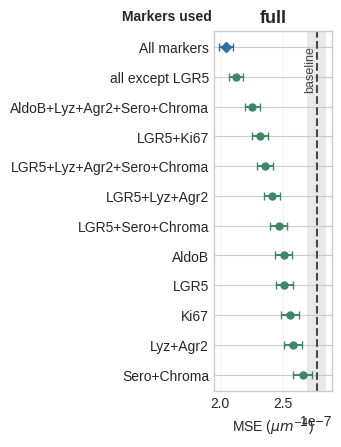

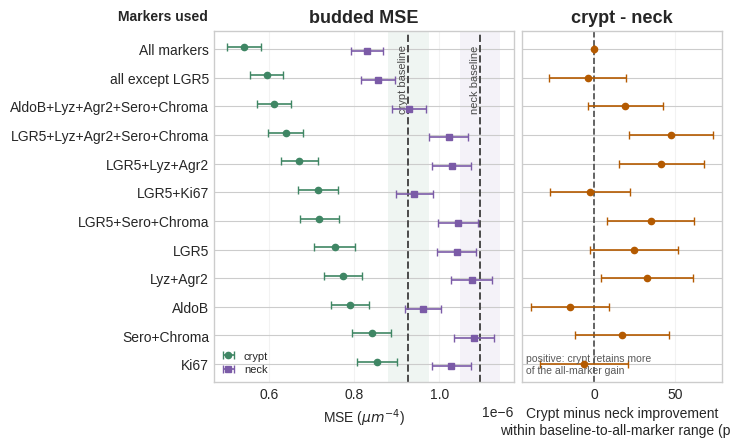

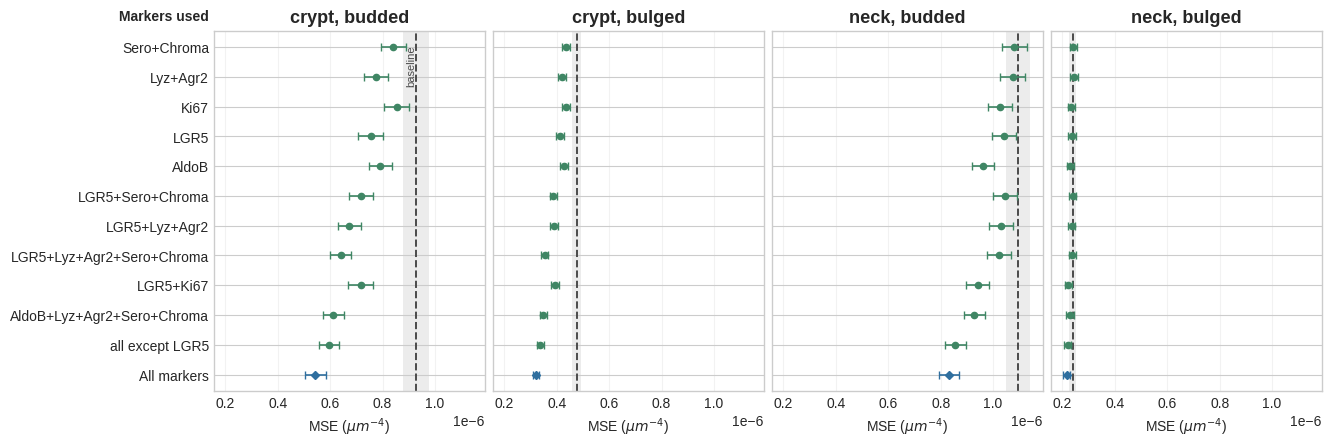

,region,depth,condition_key,plot_label,removal_key,removal_label,train_eval_key,mean_mse,sem_mse,row_type
0,full,2,original,All markers,original,Original,orig_orig,2.050160e-07,5.548663e-09,original
1,full,2,only_lgr5,LGR5,only_lgr5,LGR5 only,reduced_reduced,2.512557e-07,6.939682e-09,reduced_reduced
2,full,2,only_lysozyme_Agr2,Lyz+Agr2,only_lysozyme_Agr2,Lysozyme + Agr2 only,reduced_reduced,2.582212e-07,7.136165e-09,reduced_reduced
3,full,2,only_sero_chroma,Sero+Chroma,only_sero_chroma,Serotonin + Chroma only,reduced_reduced,2.656409e-07,7.416967e-09,reduced_reduced
4,full,2,only_aldob,AldoB,only_aldob,AldoB only,reduced_reduced,2.505478e-07,6.796625e-09,reduced_reduced
5,full,2,only_ki67,Ki67,only_ki67,KI67 only,reduced_reduced,2.559125e-07,7.074487e-09,reduced_reduced
6,full,2,remove_lgr5,all except LGR5,remove_lgr5,Remove LGR5,reduced_reduced,2.125912e-07,5.733811e-09,reduced_reduced
7,full,2,lgr5_ki67,LGR5+Ki67,lgr5_ki67,LGR5 + KI67 only,reduced_reduced,2.320935e-07,6.375170e-09,reduced_reduced
8,full,2,remove_lgr5_ki67,AldoB+Lyz+Agr2+Sero+Chroma,remove_lgr5_ki67,Remove LGR5 + KI67,reduced_reduced,2.256474e-07,6.071213e-09,reduced_reduced
9,full,2,lgr5_sero_chroma_lyso_agr2,LGR5+Lyz+Agr2+Sero+Chroma,lgr5_sero_chroma_lyso_agr2,LGR5 + Sero/Chroma\n+ Lysozyme/Agr2 only,reduced_reduced,2.358669e-07,6.543657e-09,reduced_reduced


In [78]:
LINEAGE_MARKER_DISPLAY_ORDER = [
    "LGR5",
    "KI67",
    "AldoB",
    "Lysozyme",
    "Agr2",
    "Serotonin",
    "Chroma",
    "Mucin 2",
    "Glucagon",
]
LINEAGE_MARKER_DISPLAY_NAMES = {
    "KI67": "Ki67",
    "Lysozyme": "Lyz",
    "Serotonin": "Sero",
}
LINEAGE_MARKER_NAMES = list(
    lineage_settings.get("dataset", {}).get("marker_names") or []
)
if not LINEAGE_MARKER_NAMES and not lineage_zero_counts_df.empty:
    LINEAGE_MARKER_NAMES = sorted(lineage_zero_counts_df["marker"].dropna().unique())


def _ordered_lineage_markers(markers):
    markers = [marker for marker in markers if marker in set(LINEAGE_MARKER_NAMES)]
    order = {marker: index for index, marker in enumerate(LINEAGE_MARKER_DISPLAY_ORDER)}
    return sorted(
        markers,
        key=lambda marker: (order.get(marker, len(order)), LINEAGE_MARKER_NAMES.index(marker)),
    )


def _lineage_marker_label(markers):
    markers = _ordered_lineage_markers(markers)
    if len(markers) == 0:
        return "No markers"
    if set(markers) == set(LINEAGE_MARKER_NAMES):
        return "All markers"
    if len(markers) == 6 and len(markers) == len(LINEAGE_MARKER_NAMES) - 1:
        missing = [marker for marker in LINEAGE_MARKER_NAMES if marker not in set(markers)]
        return "all except " + "+".join(
            LINEAGE_MARKER_DISPLAY_NAMES.get(marker, marker)
            for marker in _ordered_lineage_markers(missing)
        )
    return "+".join(LINEAGE_MARKER_DISPLAY_NAMES.get(marker, marker) for marker in markers)


def lineage_present_marker_label(spec):
    if spec.get("key") == "original":
        return _lineage_marker_label(LINEAGE_MARKER_NAMES)
    keep_markers = spec.get("keep_markers")
    if keep_markers is not None:
        return _lineage_marker_label(list(keep_markers))
    removed_markers = spec.get("markers")
    if removed_markers is not None:
        removed = set(removed_markers)
        return _lineage_marker_label([
            marker for marker in LINEAGE_MARKER_NAMES if marker not in removed
        ])
    return spec.get("label", spec.get("key", "Unknown"))


def lineage_depth_point_table(region, depth):
    rows = []
    region_depth = lineage_mse_df[
        (lineage_mse_df["region"] == region)
        & (lineage_mse_df["depth"].astype(float) == float(depth))
    ]
    original = region_depth[region_depth["train_eval_key"] == "orig_orig"]
    if original.empty:
        raise ValueError(f"No orig/orig result for region={region!r}, depth={depth}.")
    original_row = original.iloc[0]
    rows.append({
        "region": region,
        "depth": int(depth),
        "condition_key": "original",
        "plot_label": lineage_present_marker_label({"key": "original"}),
        "removal_key": "original",
        "removal_label": "Original",
        "train_eval_key": "orig_orig",
        "mean_mse": float(original_row["mean_mse"]),
        "sem_mse": float(original_row["sem_mse"]),
        "row_type": "original",
    })

    for spec in LINEAGE_REMOVAL_SETS:
        reduced = region_depth[
            (region_depth["removal_key"] == spec["key"])
            & (region_depth["train_eval_key"] == "reduced_reduced")
        ]
        if not reduced.empty:
            reduced_row = reduced.iloc[0]
            rows.append({
                "region": region,
                "depth": int(depth),
                "condition_key": spec["key"],
                "plot_label": lineage_present_marker_label(spec),
                "removal_key": spec["key"],
                "removal_label": spec["label"],
                "train_eval_key": "reduced_reduced",
                "mean_mse": float(reduced_row["mean_mse"]),
                "sem_mse": float(reduced_row["sem_mse"]),
                "row_type": "reduced_reduced",
            })
    return pd.DataFrame(rows)


lineage_depth_point_df = pd.concat(
    [
        lineage_depth_point_table(region, LINEAGE_POINT_DEPTH)
        for region in LINEAGE_REGION_ORDER_EFFECTIVE
    ],
    ignore_index=True,
)
lineage_depth_point_df.to_csv(
    TABLES_DIR / f"lineage_depth{LINEAGE_POINT_DEPTH}_point_summary.csv",
    index=False,
)


def lineage_depth_condition_order(region, *, sort_region=None):
    plot_df = lineage_depth_point_df[
        lineage_depth_point_df["region"] == region
    ].copy()
    sort_df = lineage_depth_point_df[
        lineage_depth_point_df["region"] == (sort_region or region)
    ].copy()

    def _condition_sort_value(group):
        for row_type in ("reduced_reduced", "original"):
            subset = group[group["row_type"] == row_type]
            if not subset.empty:
                return float(subset.iloc[0]["mean_mse"])
        return float(group["mean_mse"].iloc[0])

    condition_rows = []
    for condition_key, group in sort_df.groupby("condition_key", sort=False):
        condition_rows.append({
            "condition_key": condition_key,
            "plot_label": group["plot_label"].iloc[0],
            "sort_mse": _condition_sort_value(group),
        })
    condition_order = (
        pd.DataFrame(condition_rows)
        .sort_values("sort_mse", ascending=True)
        .reset_index(drop=True)
    )
    available_conditions = set(plot_df["condition_key"])
    condition_order = condition_order[
        condition_order["condition_key"].isin(available_conditions)
    ].reset_index(drop=True)
    return condition_order


def add_lineage_baseline(ax, region, *, label, x_text_offset=0.0, color="#4a4a4a"):
    baseline_row = lineage_baseline_df[
        lineage_baseline_df["region"] == region
    ].iloc[0]
    baseline_mean = float(baseline_row["mean_mse"])
    baseline_sem = float(baseline_row["sem_mse"])
    ax.axvspan(
        baseline_mean - baseline_sem,
        baseline_mean + baseline_sem,
        color=color,
        alpha=0.12,
        linewidth=0,
        zorder=0,
    )
    ax.axvline(
        baseline_mean,
        color=color,
        linestyle="--",
        linewidth=1.5,
        zorder=1,
    )
    ax.text(
        baseline_mean + x_text_offset,
        0.96,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="right",
        va="top",
        color=color,
        fontsize=9,
    )


def format_lineage_depth_point_axis(ax, labels, *, title):
    y = np.arange(len(labels), dtype=float)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel(f"MSE ({MSE_UNIT_LABEL})")
    ax.set_ylabel("")
    ax.text(
        -0.02,
        1.02,
        "Markers used",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=plt.rcParams["ytick.labelsize"],
        fontweight="bold",
        clip_on=False,
    )
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_title(title, fontsize=13, fontweight="bold")


def plot_lineage_depth_point_summary_full(depth):
    region = "full"
    condition_order = lineage_depth_condition_order(region)
    labels = condition_order["plot_label"].tolist()
    y = np.arange(len(labels), dtype=float)
    y_lookup = dict(zip(condition_order["condition_key"], y))
    plot_df = lineage_depth_point_df[
        lineage_depth_point_df["region"] == region
    ].copy()
    plot_df["plot_y"] = plot_df["condition_key"].map(y_lookup)
    plot_df = plot_df.dropna(subset=["plot_y"])

    fig, ax = plt.subplots(
        figsize=(3.3, 0.28 * len(labels) + 1.0),
        constrained_layout=True,
    )
    add_lineage_baseline(ax, region, label="baseline")

    original_mask = plot_df["row_type"] == "original"
    reduced_mask = plot_df["row_type"] == "reduced_reduced"
    ax.errorbar(
        plot_df.loc[reduced_mask, "mean_mse"],
        plot_df.loc[reduced_mask, "plot_y"],
        xerr=plot_df.loc[reduced_mask, "sem_mse"],
        fmt="o",
        color="#3f8664",
        ecolor="#3f8664",
        elinewidth=1.4,
        capsize=3,
        markersize=5,
        zorder=3,
    )
    ax.errorbar(
        plot_df.loc[original_mask, "mean_mse"],
        plot_df.loc[original_mask, "plot_y"],
        xerr=plot_df.loc[original_mask, "sem_mse"],
        fmt="D",
        color="#2f6f9f",
        ecolor="#2f6f9f",
        elinewidth=1.4,
        capsize=3,
        markersize=5,
        zorder=4,
    )
    format_lineage_depth_point_axis(ax, labels, title="full")
    save_figure(fig, f"lineage_depth{depth}_mse_point_summary_full")
    plt.show()
    return fig, ax


def plot_lineage_depth_point_summary_crypt_neck(depth):
    source = lineage_depth_crypt_type_point_df[
        lineage_depth_crypt_type_point_df["crypt_type"] == "budded"
    ].copy()
    if source.empty:
        raise ValueError(
            "No budded crypt/neck rows found. Rerun lineage_removal.ipynb "
            "with crypt-shape descriptors, then rerun this plotting notebook."
        )

    sort_df = source[source["region"] == "crypt"].copy()

    def _condition_sort_value(group):
        for row_type in ("reduced_reduced", "original"):
            subset = group[group["row_type"] == row_type]
            if not subset.empty:
                return float(subset.iloc[0]["mean_mse"])
        return float(group["mean_mse"].iloc[0])

    condition_order = []
    for condition_key, group in sort_df.groupby("condition_key", sort=False):
        condition_order.append({
            "condition_key": condition_key,
            "plot_label": group["plot_label"].iloc[0],
            "sort_mse": _condition_sort_value(group),
        })
    condition_order = (
        pd.DataFrame(condition_order)
        .sort_values("sort_mse", ascending=True)
        .reset_index(drop=True)
    )
    labels = condition_order["plot_label"].tolist()
    y = np.arange(len(labels), dtype=float)
    y_lookup = dict(zip(condition_order["condition_key"], y))

    plot_df = source.copy()
    plot_df["plot_y"] = plot_df["condition_key"].map(y_lookup)
    plot_df = plot_df.dropna(subset=["plot_y"])

    full_df = lineage_depth_point_df[
        (lineage_depth_point_df["region"] == "full")
        & (lineage_depth_point_df["depth"].astype(float) == float(depth))
    ].copy()
    full_df["plot_y"] = full_df["condition_key"].map(y_lookup)
    full_df = full_df.dropna(subset=["plot_y"])

    baseline_lookup = {
        row.region: row
        for row in lineage_crypt_type_baseline_df[
            lineage_crypt_type_baseline_df["crypt_type"] == "budded"
        ].itertuples(index=False)
    }
    all_marker_lookup = {}
    all_marker_rows = plot_df[plot_df["condition_key"] == "original"]
    for row in all_marker_rows.itertuples(index=False):
        all_marker_lookup[row.region] = {
            "mean": float(row.mean_mse),
            "sem": float(row.sem_mse),
        }

    anchored_rows = []
    for row in plot_df.itertuples(index=False):
        if row.region not in baseline_lookup or row.region not in all_marker_lookup:
            continue
        baseline = baseline_lookup[row.region]
        all_marker = all_marker_lookup[row.region]
        baseline_mean = float(baseline.mean_mse)
        baseline_sem = float(baseline.sem_mse)
        all_marker_mean = float(all_marker["mean"])
        all_marker_sem = float(all_marker["sem"])
        model_mean = float(row.mean_mse)
        model_sem = float(row.sem_mse)
        denom = baseline_mean - all_marker_mean
        if not np.isfinite(denom) or np.isclose(denom, 0.0):
            score = np.nan
            score_sem = np.nan
        elif row.condition_key == "original":
            score = 100.0
            score_sem = 0.0
        else:
            score = 100.0 * (baseline_mean - model_mean) / denom
            score_sem = np.sqrt(
                ((-100.0 / denom) * model_sem) ** 2
                + ((100.0 * (model_mean - all_marker_mean) / denom**2) * baseline_sem) ** 2
                + ((100.0 * (baseline_mean - model_mean) / denom**2) * all_marker_sem) ** 2
            )
        anchored_rows.append({
            "region": row.region,
            "crypt_type": row.crypt_type,
            "condition_key": row.condition_key,
            "plot_label": row.plot_label,
            "removal_key": row.removal_key,
            "removal_label": row.removal_label,
            "train_eval_key": row.train_eval_key,
            "row_type": row.row_type,
            "depth": int(depth),
            "model_mean_mse": model_mean,
            "model_sem_mse": model_sem,
            "baseline_mean_mse": baseline_mean,
            "baseline_sem_mse": baseline_sem,
            "all_markers_mean_mse": all_marker_mean,
            "all_markers_sem_mse": all_marker_sem,
            "baseline_to_all_markers_pct": score,
            "baseline_to_all_markers_sem_pct": score_sem,
            "plot_y": row.plot_y,
        })
    anchored_df = pd.DataFrame(anchored_rows)
    anchored_df.to_csv(
        TABLES_DIR / f"lineage_depth{depth}_budded_crypt_neck_baseline_to_all_markers_scale_summary.csv",
        index=False,
    )

    anchored_diff_rows = []
    for condition_key, group in anchored_df.groupby("condition_key", sort=False):
        crypt = group[group["region"] == "crypt"]
        neck = group[group["region"] == "neck"]
        if crypt.empty or neck.empty:
            continue
        crypt_row = crypt.iloc[0]
        neck_row = neck.iloc[0]
        anchored_diff_rows.append({
            "condition_key": condition_key,
            "plot_label": crypt_row["plot_label"],
            "removal_key": crypt_row["removal_key"],
            "removal_label": crypt_row["removal_label"],
            "row_type": crypt_row["row_type"],
            "depth": int(depth),
            "crypt_baseline_to_all_markers_pct": float(crypt_row["baseline_to_all_markers_pct"]),
            "crypt_baseline_to_all_markers_sem_pct": float(crypt_row["baseline_to_all_markers_sem_pct"]),
            "neck_baseline_to_all_markers_pct": float(neck_row["baseline_to_all_markers_pct"]),
            "neck_baseline_to_all_markers_sem_pct": float(neck_row["baseline_to_all_markers_sem_pct"]),
            "crypt_minus_neck_baseline_to_all_markers_pct": (
                float(crypt_row["baseline_to_all_markers_pct"])
                - float(neck_row["baseline_to_all_markers_pct"])
            ),
            "crypt_minus_neck_baseline_to_all_markers_sem_pct": np.sqrt(
                float(crypt_row["baseline_to_all_markers_sem_pct"]) ** 2
                + float(neck_row["baseline_to_all_markers_sem_pct"]) ** 2
            ),
            "plot_y": crypt_row["plot_y"],
        })
    anchored_diff_df = pd.DataFrame(anchored_diff_rows)
    anchored_diff_df.to_csv(
        TABLES_DIR / f"lineage_depth{depth}_budded_crypt_minus_neck_baseline_to_all_markers_scale_summary.csv",
        index=False,
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 0.28 * len(labels) + 1.0),
        sharey=True,
        constrained_layout=True,
        gridspec_kw={"width_ratios": [1.0, 2.0 / 3.0]},
    )
    ax_mse, ax_diff = axes

    styles = {
        "crypt": {"color": "#3f8664", "marker": "o", "label": "crypt"},
        "neck": {"color": "#7b5ba7", "marker": "s", "label": "neck"},
    }
    diff_color = "#b45a00"

    add_lineage_crypt_type_baseline(
        ax_mse,
        "crypt",
        "budded",
        label="crypt baseline",
        color=styles["crypt"]["color"],
        band_alpha=0.08,
    )
    add_lineage_crypt_type_baseline(
        ax_mse,
        "neck",
        "budded",
        label="neck baseline",
        color=styles["neck"]["color"],
        band_alpha=0.08,
    )

    offsets = {"crypt": -0.08, "neck": 0.08}
    handles = []
    labels_legend = []
    mse_sources = {
        "crypt": plot_df[plot_df["region"] == "crypt"],
        "neck": plot_df[plot_df["region"] == "neck"],
    }
    for region, region_df in mse_sources.items():
        style = styles[region]
        if region_df.empty:
            continue
        handle = ax_mse.errorbar(
            region_df["mean_mse"],
            region_df["plot_y"] + offsets[region],
            xerr=region_df["sem_mse"],
            fmt=style["marker"],
            color=style["color"],
            ecolor=style["color"],
            elinewidth=1.2,
            capsize=3,
            markersize=4.5,
            linestyle="none",
            zorder=3,
        )
        handles.append(handle)
        labels_legend.append(style["label"])

    ax_diff.axvline(0, color="#4a4a4a", linestyle="--", linewidth=1.2, zorder=1)
    ax_diff.errorbar(
        anchored_diff_df["crypt_minus_neck_baseline_to_all_markers_pct"],
        anchored_diff_df["plot_y"],
        xerr=anchored_diff_df["crypt_minus_neck_baseline_to_all_markers_sem_pct"],
        fmt="o",
        color=diff_color,
        ecolor=diff_color,
        elinewidth=1.2,
        capsize=3,
        markersize=4.5,
        linestyle="none",
        zorder=3,
    )

    format_lineage_depth_point_axis(ax_mse, labels, title="budded MSE")
    ax_mse.legend(
        handles,
        labels_legend,
        loc="lower left",
        frameon=False,
        fontsize=8,
        handlelength=1.2,
        borderpad=0.2,
        labelspacing=0.3,
    )

    ax_diff.set_yticks(y)
    ax_diff.set_yticklabels(labels)
    ax_diff.tick_params(axis="y", labelleft=False)
    ax_diff.set_xlabel("Crypt minus neck improvement\nwithin baseline-to-all-marker range (pp)")
    ax_diff.set_ylabel("")
    ax_diff.set_title("crypt - neck", fontsize=13, fontweight="bold")
    ax_diff.text(
        0.02,
        0.02,
        "positive: crypt retains more\nof the all-marker gain",
        transform=ax_diff.transAxes,
        ha="left",
        va="bottom",
        fontsize=7.5,
        color="0.35",
    )
    ax_diff.grid(axis="x", alpha=0.25)
    ax_diff.set_axisbelow(True)

    save_figure(fig, f"lineage_depth{depth}_mse_point_summary_crypt_neck")
    plt.show()
    return fig, axes



def lineage_crypt_order_labels():
    condition_order = lineage_depth_condition_order("crypt", sort_region="crypt")
    labels = condition_order["plot_label"].tolist()
    y = np.arange(len(labels), dtype=float)
    y_lookup = dict(zip(condition_order["condition_key"], y))
    return condition_order, labels, y_lookup

def _lineage_with_crypt_type(df, *, require_shape=True):
    if LINEAGE_CRYPT_TYPE_FIELD not in df.columns:
        message = (
            f"Lineage table is missing {LINEAGE_CRYPT_TYPE_FIELD!r}. "
            "Rerun lineage_removal.ipynb after the crypt-shape descriptor update."
        )
        if require_shape:
            raise ValueError(message)
        out = df.copy()
        out["crypt_type"] = pd.Series(np.nan, index=out.index, dtype=object)
        return out
    out = df.copy()
    shape = pd.to_numeric(out[LINEAGE_CRYPT_TYPE_FIELD], errors="coerce")
    out["crypt_type"] = pd.Series(np.nan, index=out.index, dtype=object)
    out.loc[
        shape < float(LINEAGE_BUDDED_MAX_SIGNED_NECK_SHAPE),
        "crypt_type",
    ] = "budded"
    out.loc[
        shape >= float(LINEAGE_BULGED_MIN_SIGNED_NECK_SHAPE),
        "crypt_type",
    ] = "bulged"
    return out.dropna(subset=["crypt_type"])


def summarize_lineage_stratified_mse(df, group_columns):
    def summarize(group):
        values = pd.to_numeric(group["mse"], errors="coerce").to_numpy(float)
        values = values[np.isfinite(values)]
        n = len(values)
        std = float(np.std(values, ddof=1)) if n > 1 else 0.0
        return pd.Series({
            "mean_mse": float(np.mean(values)) if n else np.nan,
            "std_mse": std if n else np.nan,
            "sem_mse": std / np.sqrt(n) if n else np.nan,
            "n_organoids": int(n),
            "n_nodes": int(pd.to_numeric(group["n_nodes"], errors="coerce").sum()),
        })

    return (
        df.groupby(group_columns, dropna=False, sort=False)
        .apply(summarize, include_groups=False)
        .reset_index()
    )


def lineage_depth_crypt_type_point_table(depth):
    source = _lineage_with_crypt_type(
        lineage_organoid_mse_df[
            lineage_organoid_mse_df["region"].isin(["crypt", "neck"])
            & (lineage_organoid_mse_df["depth"].astype(float) == float(depth))
        ]
    )
    if source.empty:
        raise ValueError(
            "No crypt/neck organoid-level lineage rows with finite crypt-shape "
            f"values for depth={depth}."
        )

    original = source[source["train_eval_key"] == "orig_orig"].drop_duplicates(
        subset=["fold", "organoid_id", "depth", "region", "crypt_type"]
    ).copy()
    original["condition_key"] = "original"
    original["plot_label"] = lineage_present_marker_label({"key": "original"})
    original["removal_key"] = "original"
    original["removal_label"] = "Original"
    original["row_type"] = "original"

    reduced = source[source["train_eval_key"] == "reduced_reduced"].copy()
    label_lookup = {
        spec["key"]: lineage_present_marker_label(spec)
        for spec in LINEAGE_REMOVAL_SETS
    }
    reduced["condition_key"] = reduced["removal_key"]
    reduced["plot_label"] = reduced["removal_key"].map(label_lookup).fillna(
        reduced["removal_label"]
    )
    reduced["row_type"] = "reduced_reduced"

    combined = pd.concat([original, reduced], ignore_index=True, sort=False)
    summary = summarize_lineage_stratified_mse(
        combined,
        [
            "region",
            "crypt_type",
            "condition_key",
            "plot_label",
            "removal_key",
            "removal_label",
            "train_eval_key",
            "row_type",
            "depth",
        ],
    )
    summary["depth"] = summary["depth"].astype(int)
    return summary


def lineage_crypt_type_baseline_table():
    source = _lineage_with_crypt_type(
        lineage_baseline_organoid_mse_df[
            lineage_baseline_organoid_mse_df["region"].isin(["crypt", "neck"])
        ]
    )
    if source.empty:
        raise ValueError(
            "No crypt/neck baseline rows with finite crypt-shape values."
        )
    return summarize_lineage_stratified_mse(
        source,
        ["region", "crypt_type"],
    )


lineage_depth_crypt_type_point_df = lineage_depth_crypt_type_point_table(
    LINEAGE_POINT_DEPTH
)
lineage_crypt_type_baseline_df = lineage_crypt_type_baseline_table()
lineage_depth_crypt_type_point_df.to_csv(
    TABLES_DIR / f"lineage_depth{LINEAGE_POINT_DEPTH}_mse_point_summary_crypt_types.csv",
    index=False,
)
lineage_crypt_type_baseline_df.to_csv(
    TABLES_DIR / "lineage_crypt_type_global_baseline_summary.csv",
    index=False,
)


def add_lineage_crypt_type_baseline(
    ax,
    region,
    crypt_type,
    *,
    label="baseline",
    color="#4a4a4a",
    band_alpha=0.10,
):
    row = lineage_crypt_type_baseline_df[
        (lineage_crypt_type_baseline_df["region"] == region)
        & (lineage_crypt_type_baseline_df["crypt_type"] == crypt_type)
    ]
    if row.empty:
        return
    row = row.iloc[0]
    baseline_mean = float(row["mean_mse"])
    baseline_sem = float(row["sem_mse"])
    ax.axvspan(
        baseline_mean - baseline_sem,
        baseline_mean + baseline_sem,
        color=color,
        alpha=band_alpha,
        linewidth=0,
        zorder=0,
    )
    ax.axvline(
        baseline_mean,
        color="#4a4a4a",
        linestyle="--",
        linewidth=1.4,
        zorder=1,
    )
    ax.text(
        baseline_mean,
        0.96,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="right",
        va="top",
        color="#4a4a4a",
        fontsize=8,
    )


def plot_lineage_depth_point_summary_crypt_types(depth):
    condition_order = lineage_depth_condition_order("full", sort_region="full")
    labels = condition_order["plot_label"].tolist()
    y = np.arange(len(labels), dtype=float)
    y_lookup = dict(zip(condition_order["condition_key"], y))

    plot_df = lineage_depth_crypt_type_point_df.copy()
    plot_df["plot_y"] = plot_df["condition_key"].map(y_lookup)
    plot_df = plot_df.dropna(subset=["plot_y"])

    panels = [
        {"region": "crypt", "crypt_type": "budded", "title": "crypt, budded"},
        {"region": "crypt", "crypt_type": "bulged", "title": "crypt, bulged"},
        {"region": "neck", "crypt_type": "budded", "title": "neck, budded"},
        {"region": "neck", "crypt_type": "bulged", "title": "neck, bulged"},
    ]
    fig, axes = plt.subplots(
        1,
        4,
        figsize=(13.2, 0.28 * len(labels) + 1.0),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for panel, ax in zip(panels, axes):
        region = panel["region"]
        crypt_type = panel["crypt_type"]
        panel_df = plot_df[
            (plot_df["region"] == region)
            & (plot_df["crypt_type"] == crypt_type)
        ].copy()
        add_lineage_crypt_type_baseline(ax, region, crypt_type)

        original_mask = panel_df["row_type"] == "original"
        reduced_mask = panel_df["row_type"] == "reduced_reduced"
        ax.errorbar(
            panel_df.loc[reduced_mask, "mean_mse"],
            panel_df.loc[reduced_mask, "plot_y"],
            xerr=panel_df.loc[reduced_mask, "sem_mse"],
            fmt="o",
            color="#3f8664",
            ecolor="#3f8664",
            elinewidth=1.2,
            capsize=3,
            markersize=4.5,
            linestyle="none",
            zorder=3,
        )
        ax.errorbar(
            panel_df.loc[original_mask, "mean_mse"],
            panel_df.loc[original_mask, "plot_y"],
            xerr=panel_df.loc[original_mask, "sem_mse"],
            fmt="D",
            color="#2f6f9f",
            ecolor="#2f6f9f",
            elinewidth=1.2,
            capsize=3,
            markersize=4.5,
            linestyle="none",
            zorder=4,
        )
        format_lineage_depth_point_axis(ax, labels, title=panel["title"])
        ax.tick_params(axis="y", labelleft=(ax is axes[0]))
        if ax is not axes[0]:
            for text in list(ax.texts):
                text.remove()
            ax.set_ylabel("")

    save_figure(fig, f"lineage_depth{depth}_mse_point_summary_crypt_type_panels")
    plt.show()
    return fig, axes

def clean_stale_lineage_depth_point_figures(depth):
    stale_stems = [
        f"lineage_depth{depth}_mse_point_summary_crypt",
        f"lineage_depth{depth}_mse_point_summary_neck",
        f"lineage_depth{depth}_mse_point_summary_villus",
        f"lineage_depth{depth}_relative_improvement_crypt_neck",
        f"lineage_depth{depth}_relative_improvement_difference_crypt_minus_neck",
    ]
    for stem in stale_stems:
        for path in FIGURES_DIR.glob(f"{stem}.*"):
            if path.is_file():
                path.unlink()


clean_stale_lineage_depth_point_figures(LINEAGE_POINT_DEPTH)
lineage_depth_point_figures = {
    "full": plot_lineage_depth_point_summary_full(LINEAGE_POINT_DEPTH),
    "crypt_neck": plot_lineage_depth_point_summary_crypt_neck(LINEAGE_POINT_DEPTH),
    "crypt_type_panels": plot_lineage_depth_point_summary_crypt_types(LINEAGE_POINT_DEPTH),
}
display(lineage_depth_point_df)


### Focused Full-Region Lineage Curves

This compact figure compares the all-marker model with the LGR5-only and without-LGR5 reduced/reduced conditions in the full-region evaluation.


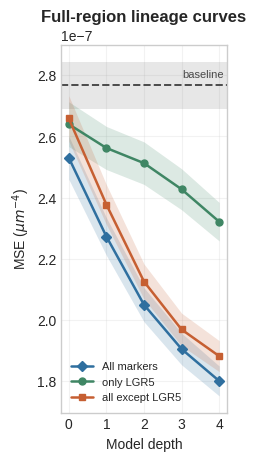

In [79]:
FOCUSED_LINEAGE_REGION = "full"


def find_lineage_removal_spec(predicate, description):
    matches = [spec for spec in LINEAGE_REMOVAL_SETS if predicate(spec)]
    if not matches:
        raise ValueError(f"Could not find lineage removal set for {description}.")
    return matches[0]


def lineage_curve_table(region, train_eval_key, removal_key=None):
    mask = (
        (lineage_mse_df["region"] == region)
        & (lineage_mse_df["train_eval_key"] == train_eval_key)
    )
    if removal_key is not None:
        mask &= lineage_mse_df["removal_key"] == removal_key
    curve = lineage_mse_df.loc[mask].copy()
    if curve.empty:
        raise ValueError(
            f"No lineage curve rows for region={region!r}, "
            f"train_eval_key={train_eval_key!r}, removal_key={removal_key!r}."
        )
    curve["depth"] = curve["depth"].astype(int)
    # orig/orig is duplicated across removal settings in the saved table; keep
    # one value per depth after checking the grouping level.
    return (
        curve.groupby("depth", as_index=False)
        .agg(mean_mse=("mean_mse", "first"), sem_mse=("sem_mse", "first"))
        .sort_values("depth")
    )


lgr5_only_spec = find_lineage_removal_spec(
    lambda spec: set(spec.get("keep_markers") or []) == {"LGR5"},
    "LGR5 only",
)
without_lgr5_spec = find_lineage_removal_spec(
    lambda spec: set(spec.get("markers") or []) == {"LGR5"},
    "without LGR5",
)

focused_lineage_curves = [
    {
        "label": "All markers",
        "curve": lineage_curve_table(FOCUSED_LINEAGE_REGION, "orig_orig"),
        "color": "#2f6f9f",
        "marker": "D",
    },
    {
        "label": "only LGR5",
        "curve": lineage_curve_table(
            FOCUSED_LINEAGE_REGION,
            "reduced_reduced",
            lgr5_only_spec["key"],
        ),
        "color": "#3f8664",
        "marker": "o",
    },
    {
        "label": lineage_present_marker_label(without_lgr5_spec),
        "curve": lineage_curve_table(
            FOCUSED_LINEAGE_REGION,
            "reduced_reduced",
            without_lgr5_spec["key"],
        ),
        "color": "#c65f32",
        "marker": "s",
    },
]

focused_baseline_row = lineage_baseline_df[
    lineage_baseline_df["region"] == FOCUSED_LINEAGE_REGION
].iloc[0]
focused_baseline_mean = float(focused_baseline_row["mean_mse"])
focused_baseline_sem = float(focused_baseline_row["sem_mse"])

fig, ax = plt.subplots(figsize=(2.25, 4.5), constrained_layout=True)
ax.axhspan(
    focused_baseline_mean - focused_baseline_sem,
    focused_baseline_mean + focused_baseline_sem,
    color="#6b6b6b",
    alpha=0.16,
    linewidth=0,
)
ax.axhline(
    focused_baseline_mean,
    color="#4a4a4a",
    linestyle="--",
    linewidth=1.4,
)
label_horizontal_baseline(ax, focused_baseline_mean, fontsize=8)
for item in focused_lineage_curves:
    curve = item["curve"]
    x = curve["depth"].to_numpy(float)
    y = curve["mean_mse"].to_numpy(float)
    sem = curve["sem_mse"].to_numpy(float)
    ax.plot(
        x,
        y,
        color=item["color"],
        marker=item["marker"],
        linewidth=1.8,
        markersize=5,
        label=item["label"],
    )
    ax.fill_between(
        x,
        y - sem,
        y + sem,
        color=item["color"],
        alpha=0.18,
        linewidth=0,
    )

ax.set_xticks(LINEAGE_MODEL_DEPTHS)
ax.set_xlabel("Model depth")
ax.set_ylabel(f"MSE ({MSE_UNIT_LABEL})")
ax.set_title("Full-region lineage curves", fontsize=12, fontweight="bold")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=8, loc="lower left")
save_figure(fig, "lineage_focused_full_region_curves")
plt.show()


In [80]:
if not lineage_zero_counts_df.empty:
    zero_summary = (
        lineage_zero_counts_df
        .groupby(["removal_label", "marker"], as_index=False)
        [["train_positive_values_zeroed", "val_positive_values_zeroed"]]
        .sum()
    )
    display(zero_summary)

,removal_label,marker,train_positive_values_zeroed,val_positive_values_zeroed
0,AldoB only,Agr2,79488,19872
1,AldoB only,Chroma,6796,1699
2,AldoB only,KI67,477276,119319
3,AldoB only,LGR5,236668,59167
4,AldoB only,Lysozyme,21300,5325
5,AldoB only,Serotonin,5920,1480
6,KI67 only,Agr2,79488,19872
7,KI67 only,AldoB,638020,159505
8,KI67 only,Chroma,6796,1699
9,KI67 only,LGR5,236668,59167


## Supplemental Composition And Permutation Figures

Compact figures from saved `signal_composition_analysis.ipynb` and `permutations_tests.ipynb` result tables.


In [81]:
REQUIRED_SUPPLEMENT_TABLES = {
    "summary": "summary_metrics.csv",
    "markerwise": "markerwise_metrics.csv",
    "aggregate": "aggregate_metrics.csv",
    "global": "global_metrics.csv",
}
REQUIRED_SIGNAL_COMPOSITION_EXPERIMENTS = {
    "exp1_original",
    "exp2_fully_permuted",
    "exp3_ring_preserving_permuted",
}

SUPPLEMENT_FAMILY_ORDER = [
    "GIN | global",
    "GIN | no-global",
    "GIN",
    "ring-fraction | global",
    "ring-fraction | no-global",
    "ring",
    "ring-size | global",
    "ring-size | no-global",
    "ring-size",
]
SUPPLEMENT_FAMILY_LABELS = {
    "GIN | global": "GNN",
    "GIN | no-global": "GNN no global",
    "GIN": "GNN",
    "ring-fraction | global": "Ring fraction",
    "ring-fraction | no-global": "Ring fraction no global",
    "ring": "Ring fraction",
    "ring-size | global": "Ring size",
    "ring-size | no-global": "Ring size no global",
    "ring-size": "Ring size",
}
SUPPLEMENT_FAMILY_COLORS = {
    "GIN | global": "#2f6f9f",
    "GIN | no-global": "#7aa6c2",
    "GIN": "#2f6f9f",
    "ring-fraction | global": "#c65f32",
    "ring-fraction | no-global": "#e0a07f",
    "ring": "#c65f32",
    "ring-size | global": "#7b5aa6",
    "ring-size | no-global": "#b8a3d4",
    "ring-size": "#7b5aa6",
}
MARKER_DISPLAY_NAMES = {
    "KI67": "Ki67",
    "Lysozyme": "Lyz",
    "Serotonin": "Sero",
}
MARKER_PANEL_ORDER = ["LGR5", "KI67", "AldoB", "Lysozyme", "Agr2", "Serotonin", "Chroma", "no_marker"]


def is_complete_metric_run(run_dir):
    run_dir = Path(run_dir)
    tables_dir = run_dir / "tables"
    return all((tables_dir / filename).exists() for filename in REQUIRED_SUPPLEMENT_TABLES.values())


def has_required_signal_composition_experiments(run_dir):
    run_dir = Path(run_dir)
    if not is_complete_metric_run(run_dir):
        return False
    summary_path = run_dir / "tables" / REQUIRED_SUPPLEMENT_TABLES["summary"]
    try:
        summary = pd.read_csv(summary_path, usecols=["experiment"])
    except Exception:
        return False
    experiments = set(summary["experiment"].dropna().astype(str))
    if not REQUIRED_SIGNAL_COMPOSITION_EXPERIMENTS.issubset(experiments):
        return False

    try:
        settings = load_json(result_settings_path(run_dir))
    except (FileNotFoundError, json.JSONDecodeError):
        return False
    experiment_2_note = str(settings.get("sampling", {}).get("experiment_2", "")).lower()
    has_train_eval_permutation_note = (
        "trained on fully permuted training graphs" in experiment_2_note
        and "evaluated on fully permuted validation graphs" in experiment_2_note
    )
    return has_train_eval_permutation_note


def discover_latest_signal_composition_run(root):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(root)
    candidates = [
        path for path in root.iterdir()
        if path.is_dir() and has_required_signal_composition_experiments(path)
    ]
    if not candidates:
        raise FileNotFoundError(
            "No complete signal_composition_analysis run with experiments "
            f"{sorted(REQUIRED_SIGNAL_COMPOSITION_EXPERIMENTS)} found under {root}. "
            "Rerun experiments/signal_composition_analysis.ipynb after the full train/eval permutation update."
        )
    return max(candidates, key=lambda path: path.stat().st_mtime)


def load_metric_run(run_dir):
    run_dir = Path(run_dir).expanduser().resolve()
    if not has_required_signal_composition_experiments(run_dir):
        raise FileNotFoundError(
            f"{run_dir} is missing one of the required signal-composition experiments: "
            f"{sorted(REQUIRED_SIGNAL_COMPOSITION_EXPERIMENTS)}"
        )
    tables = {
        key: pd.read_csv(run_dir / "tables" / filename)
        for key, filename in REQUIRED_SUPPLEMENT_TABLES.items()
    }
    settings = load_json(result_settings_path(run_dir))
    return {"run_dir": run_dir, "settings": settings, "tables": tables}


signal_composition_run_dir = (
    discover_latest_signal_composition_run(SIGNAL_COMPOSITION_RESULTS_ROOT)
    if SIGNAL_COMPOSITION_RUN_DIR is None
    else Path(SIGNAL_COMPOSITION_RUN_DIR).expanduser().resolve()
)
signal_composition_run = load_metric_run(signal_composition_run_dir)

signal_summary = signal_composition_run["tables"]["summary"].copy()
signal_markerwise = signal_composition_run["tables"]["markerwise"].copy()
signal_aggregate = signal_composition_run["tables"]["aggregate"].copy()
signal_global = signal_composition_run["tables"]["global"].copy()

signal_summary = scale_all_mse_columns(signal_summary)
signal_markerwise = scale_all_mse_columns(signal_markerwise)
signal_aggregate = scale_all_mse_columns(signal_aggregate)
signal_global = scale_all_mse_columns(signal_global)

signal_summary.to_csv(TABLES_DIR / "supplement_signal_composition_summary_metrics.csv", index=False)
signal_markerwise.to_csv(TABLES_DIR / "supplement_signal_composition_markerwise_metrics.csv", index=False)
signal_aggregate.to_csv(TABLES_DIR / "supplement_signal_composition_aggregate_metrics.csv", index=False)
signal_global.to_csv(TABLES_DIR / "supplement_signal_composition_global_metrics.csv", index=False)

supplement_run_summary = pd.DataFrame([
    {"analysis": "signal_composition", "run_dir": str(signal_composition_run_dir)},
])
supplement_run_summary.to_csv(TABLES_DIR / "supplement_signal_composition_run_summary.csv", index=False)
display(supplement_run_summary)


def ordered_families(df):
    present = list(dict.fromkeys(df["family"].tolist()))
    order = {family: idx for idx, family in enumerate(SUPPLEMENT_FAMILY_ORDER)}
    return sorted(present, key=lambda family: (order.get(family, len(order)), family))


def marker_display_name(marker):
    if str(marker) == "no_marker":
        return "No markers"
    return MARKER_DISPLAY_NAMES.get(marker, marker)


def ordered_markers(df):
    present = list(dict.fromkeys(df["marker"].tolist()))
    order = {marker: idx for idx, marker in enumerate(MARKER_PANEL_ORDER)}
    return sorted(present, key=lambda marker: (order.get(marker, len(order)), marker_display_name(marker)))


def supplement_x_label(df):
    families = set(df["family"].dropna().astype(str)) if "family" in df else set()
    has_non_gnn = any(not family.startswith("GIN") for family in families)
    return "neighborhood radius (graph hops)" if has_non_gnn else "Depth"


def label_curve_end(ax, x, y, label="baseline", *, color="#4a4a4a", fontsize=7.5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    if not np.any(finite):
        return
    x_last = x[finite][-1]
    y_last = y[finite][-1]
    ax.annotate(
        label,
        xy=(x_last, y_last),
        xytext=(3, 3),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=fontsize,
        color=color,
    )


def aggregate_as_markerwise(aggregate_df, *, experiment=None, marker="no_marker"):
    out = aggregate_df.copy()
    if experiment is not None and "experiment" in out.columns:
        out = out[out["experiment"] == experiment].copy()
    out = out[out["aggregate"] == marker].copy()
    if out.empty:
        return out
    out["marker"] = marker
    return out


def plot_overall_reference_curve(ax, overall, *, color, label, linestyle="-.", linewidth=0.95):
    overall = overall.sort_values("depth")
    x = overall["depth"].to_numpy(float)
    y = overall["mse_all_nodes"].to_numpy(float)
    sem = overall["sem_mse_all_nodes"].to_numpy(float)
    line, = ax.plot(x, y, color=color, linestyle=linestyle, linewidth=linewidth, label=label)
    ax.fill_between(x, y - sem, y + sem, color=color, alpha=0.12, linewidth=0)
    return line


def add_metric_curve(ax, curve, *, x_col="depth", y_col="mse_all_nodes", sem_col="sem_mse_all_nodes", color, label, marker="o", linewidth=1.4):
    curve = curve.sort_values(x_col)
    x = curve[x_col].to_numpy(float)
    y = curve[y_col].to_numpy(float)
    sem = curve[sem_col].to_numpy(float) if sem_col in curve else np.zeros_like(y)
    line, = ax.plot(x, y, color=color, marker=marker, linewidth=linewidth, markersize=3.4, label=label)
    ax.fill_between(x, y - sem, y + sem, color=color, alpha=0.16, linewidth=0)
    return line


def extend_band_values(values, table, y_col, sem_col):
    if table.empty:
        return
    y = table[y_col].to_numpy(float)
    sem = table[sem_col].to_numpy(float) if sem_col in table else np.zeros_like(y)
    finite = np.isfinite(y) & np.isfinite(sem)
    values.extend((y[finite] - sem[finite]).tolist())
    values.extend((y[finite] + sem[finite]).tolist())


def apply_shared_ylim(axes, values, *, pad_fraction=0.06):
    finite = np.asarray([value for value in values if np.isfinite(value)], dtype=float)
    if finite.size == 0:
        return
    ymin = float(np.min(finite))
    ymax = float(np.max(finite))
    span = ymax - ymin
    if span <= 0:
        span = max(abs(ymin), 1.0) * 0.05
    pad = span * pad_fraction
    for ax in axes:
        ax.set_ylim(ymin - pad, ymax + pad)


def draw_marker_label(ax, marker):
    ax.text(
        0.04,
        0.94,
        marker_display_name(marker),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.6,
        fontweight="bold",
        bbox={"facecolor": "white", "alpha": 0.72, "edgecolor": "none", "pad": 1.5},
    )


,analysis,run_dir
0,signal_composition,/home/fmoller/Projects/LearningOrganoids/Graph...


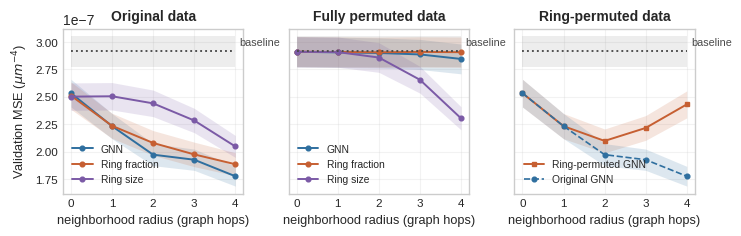

In [82]:
case_specs = [
    {
        "title": "Original data",
        "data": signal_summary[signal_summary["experiment"] == "exp1_original"].copy(),
        "mode": "families",
        "baseline": "case",
    },
    {
        "title": "Fully permuted data",
        "data": signal_summary[signal_summary["experiment"] == "exp2_fully_permuted"].copy(),
        "mode": "families",
        "baseline": "original",
    },
    {
        "title": "Ring-permuted data",
        "data": signal_summary[signal_summary["experiment"] == "exp3_ring_preserving_permuted"].copy(),
        "mode": "ring_with_original_reference",
        "baseline": "case",
    },
]
original_gnn_summary = signal_summary[
    (signal_summary["experiment"] == "exp1_original")
    & (signal_summary["family"] == "GIN | global")
].copy()

fig, axes = plt.subplots(1, 3, figsize=(7.3, 2.25), sharey=True, constrained_layout=True)
for ax, case in zip(axes, case_specs):
    case_df = case["data"]
    panel_handles = []
    panel_labels = []
    if case["mode"] == "ring_with_original_reference":
        ring_gnn = case_df[case_df["family"] == "GIN | global"]
        handle = add_metric_curve(
            ax,
            ring_gnn,
            color="#c65f32",
            label="Ring-permuted GNN",
            marker="s",
        )
        panel_handles.append(handle)
        panel_labels.append("Ring-permuted GNN")
        original_handle = add_metric_curve(
            ax,
            original_gnn_summary,
            color="#2f6f9f",
            label="Original GNN",
            marker="o",
            linewidth=1.2,
        )
        original_handle.set_linestyle("--")
        panel_handles.append(original_handle)
        panel_labels.append("Original GNN")
    else:
        seen_labels = set()
        for family in ordered_families(case_df):
            curve = case_df[case_df["family"] == family]
            label = SUPPLEMENT_FAMILY_LABELS.get(family, family)
            handle = add_metric_curve(
                ax,
                curve,
                color=SUPPLEMENT_FAMILY_COLORS.get(family, "#4a4a4a"),
                label=label,
            )
            if label not in seen_labels:
                panel_handles.append(handle)
                panel_labels.append(label)
                seen_labels.add(label)

    if case["baseline"] == "original":
        baseline_source = original_gnn_summary
    else:
        baseline_source = case_df
        if "GIN | global" in set(baseline_source["family"]):
            baseline_source = baseline_source[baseline_source["family"] == "GIN | global"]
        elif "GIN" in set(baseline_source["family"]):
            baseline_source = baseline_source[baseline_source["family"] == "GIN"]
    baseline = (
        baseline_source[["depth", "mse_base_all_nodes", "sem_mse_base_all_nodes"]]
        .drop_duplicates()
        .sort_values("depth")
    )
    x = baseline["depth"].to_numpy(float)
    y = baseline["mse_base_all_nodes"].to_numpy(float)
    sem = baseline["sem_mse_base_all_nodes"].to_numpy(float)
    ax.plot(x, y, color="#4a4a4a", linestyle=":", linewidth=1.35)
    ax.fill_between(x, y - sem, y + sem, color="#6b6b6b", alpha=0.12, linewidth=0)
    label_curve_end(ax, x, y, fontsize=7.8)

    ax.legend(panel_handles, panel_labels, frameon=False, fontsize=7.4, loc="lower left")
    ax.set_title(case["title"], fontsize=10.0, fontweight="bold")
    ax.set_xlabel("neighborhood radius (graph hops)", fontsize=9.2)
    ax.tick_params(labelsize=8.4)
    ax.grid(alpha=0.25)
axes[0].set_ylabel(f"Validation MSE ({MSE_UNIT_LABEL})", fontsize=9.2)
save_figure(fig, "supplement_all_node_mse_original_full_permuted_ring_permuted")
plt.show()


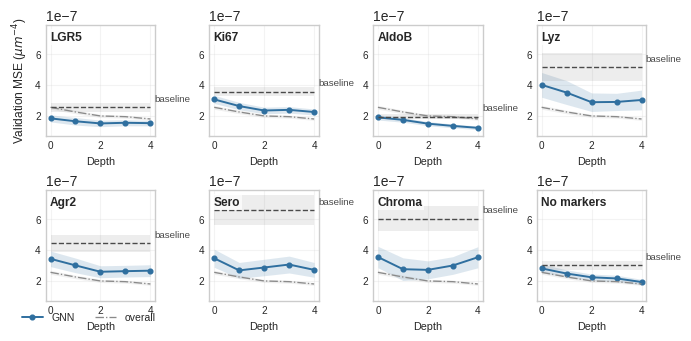

In [83]:
gin_original_markerwise = signal_markerwise[
    (signal_markerwise["experiment"] == "exp1_original")
    & (signal_markerwise["family"] == "GIN | global")
].copy()
gin_original_no_marker = aggregate_as_markerwise(
    signal_aggregate[signal_aggregate["family"] == "GIN | global"],
    experiment="exp1_original",
    marker="no_marker",
)
gin_original_markerwise = pd.concat(
    [gin_original_markerwise, gin_original_no_marker],
    ignore_index=True,
    sort=False,
)
overall_original_gnn = signal_summary[
    (signal_summary["experiment"] == "exp1_original")
    & (signal_summary["family"] == "GIN | global")
].copy()
markers_for_plot = ordered_markers(gin_original_markerwise)

ylim_values = []
extend_band_values(ylim_values, overall_original_gnn, "mse_all_nodes", "sem_mse_all_nodes")
for marker in markers_for_plot:
    curve = gin_original_markerwise[gin_original_markerwise["marker"] == marker]
    extend_band_values(ylim_values, curve, "mse_model", "sem_mse_model")
    baseline = curve[["depth", "mse_base", "sem_mse_base"]].drop_duplicates()
    extend_band_values(ylim_values, baseline, "mse_base", "sem_mse_base")

n_cols = 4
n_rows = int(np.ceil(len(markers_for_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.8, 1.65 * n_rows), sharex=True, sharey=False, constrained_layout=True)
axes = np.asarray(axes).ravel()
legend_handles = []
for ax, marker in zip(axes, markers_for_plot):
    curve = gin_original_markerwise[gin_original_markerwise["marker"] == marker].sort_values("depth")
    handle = add_metric_curve(
        ax,
        curve,
        y_col="mse_model",
        sem_col="sem_mse_model",
        color="#2f6f9f",
        label="GNN",
    )
    overall_line = plot_overall_reference_curve(
        ax,
        overall_original_gnn,
        color="#8a8a8a",
        label="overall",
    )
    baseline = curve[["depth", "mse_base", "sem_mse_base"]].drop_duplicates().sort_values("depth")
    x = baseline["depth"].to_numpy(float)
    y = baseline["mse_base"].to_numpy(float)
    sem = baseline["sem_mse_base"].to_numpy(float)
    ax.plot(x, y, color="#4a4a4a", linestyle="--", linewidth=1.0)
    ax.fill_between(x, y - sem, y + sem, color="#6b6b6b", alpha=0.12, linewidth=0)
    label_curve_end(ax, x, y, fontsize=7.0)
    draw_marker_label(ax, marker)
    ax.set_xlabel("Depth", fontsize=7.8)
    ax.tick_params(labelsize=7.2, labelbottom=True)
    ax.grid(alpha=0.22)
    if not legend_handles:
        legend_handles = [handle, overall_line]
plot_axes = axes[:len(markers_for_plot)]
apply_shared_ylim(plot_axes, ylim_values)
for ax in axes[len(markers_for_plot):]:
    ax.axis("off")
if len(markers_for_plot) < len(axes):
    axes[len(markers_for_plot)].legend(legend_handles, [h.get_label() for h in legend_handles], frameon=False, fontsize=7.5, loc="lower left")
else:
    fig.legend(legend_handles, [h.get_label() for h in legend_handles], loc="lower left", bbox_to_anchor=(0.01, 0.01), ncol=2, fontsize=7.5, frameon=False)
axes[0].set_ylabel(f"Validation MSE ({MSE_UNIT_LABEL})", fontsize=8.6)
save_figure(fig, "supplement_gin_markerwise_validation_mse")
plt.show()


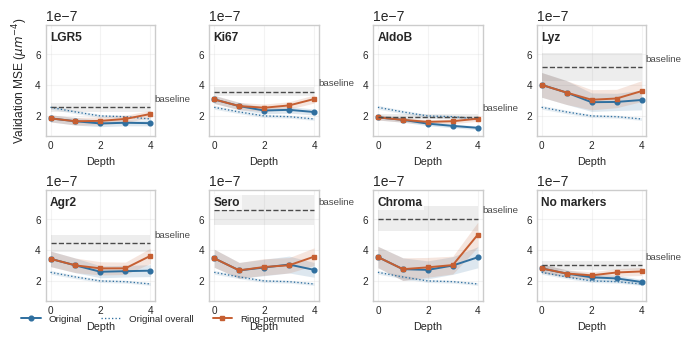

In [84]:
gin_ring_markerwise = signal_markerwise[
    (signal_markerwise["experiment"].isin(["exp1_original", "exp3_ring_preserving_permuted"]))
    & (signal_markerwise["family"] == "GIN | global")
].copy()
gin_ring_no_marker = aggregate_as_markerwise(
    signal_aggregate[signal_aggregate["family"] == "GIN | global"],
    marker="no_marker",
)
gin_ring_no_marker = gin_ring_no_marker[
    gin_ring_no_marker["experiment"].isin(["exp1_original", "exp3_ring_preserving_permuted"])
].copy()
gin_ring_markerwise = pd.concat(
    [gin_ring_markerwise, gin_ring_no_marker],
    ignore_index=True,
    sort=False,
)
overall_ring_summary = signal_summary[
    (signal_summary["experiment"].isin(["exp1_original", "exp3_ring_preserving_permuted"]))
    & (signal_summary["family"] == "GIN | global")
].copy()
markers_for_plot = ordered_markers(gin_ring_markerwise)
condition_styles = {
    "exp1_original": {"label": "Original", "color": "#2f6f9f", "marker": "o", "overall_label": "Original overall"},
    "exp3_ring_preserving_permuted": {"label": "Ring-permuted", "color": "#c65f32", "marker": "s"},
}

ylim_values = []
for experiment in condition_styles:
    overall = overall_ring_summary[overall_ring_summary["experiment"] == experiment]
    extend_band_values(ylim_values, overall, "mse_all_nodes", "sem_mse_all_nodes")
for marker in markers_for_plot:
    marker_curves = gin_ring_markerwise[gin_ring_markerwise["marker"] == marker]
    for experiment in condition_styles:
        curve = marker_curves[marker_curves["experiment"] == experiment]
        extend_band_values(ylim_values, curve, "mse_model", "sem_mse_model")
    baseline_source = marker_curves[marker_curves["experiment"] == "exp3_ring_preserving_permuted"]
    if baseline_source.empty:
        baseline_source = marker_curves[marker_curves["experiment"] == "exp1_original"]
    baseline = baseline_source[["depth", "mse_base", "sem_mse_base"]].drop_duplicates()
    extend_band_values(ylim_values, baseline, "mse_base", "sem_mse_base")

n_cols = 4
n_rows = int(np.ceil(len(markers_for_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.8, 1.65 * n_rows), sharex=True, sharey=False, constrained_layout=True)
axes = np.asarray(axes).ravel()
legend_handles = {}
for ax, marker in zip(axes, markers_for_plot):
    marker_curves = gin_ring_markerwise[gin_ring_markerwise["marker"] == marker]
    for experiment, style in condition_styles.items():
        curve = marker_curves[marker_curves["experiment"] == experiment].sort_values("depth")
        if curve.empty:
            continue
        handle = add_metric_curve(
            ax,
            curve,
            y_col="mse_model",
            sem_col="sem_mse_model",
            color=style["color"],
            label=style["label"],
            marker=style["marker"],
        )
        legend_handles.setdefault(style["label"], handle)
        if experiment == "exp1_original":
            overall = overall_ring_summary[overall_ring_summary["experiment"] == experiment]
            overall_line = plot_overall_reference_curve(
                ax,
                overall,
                color=style["color"],
                label=style["overall_label"],
                linestyle=":",
            )
            legend_handles.setdefault(style["overall_label"], overall_line)

    baseline_source = marker_curves[marker_curves["experiment"] == "exp3_ring_preserving_permuted"]
    if baseline_source.empty:
        baseline_source = marker_curves[marker_curves["experiment"] == "exp1_original"]
    baseline = baseline_source[["depth", "mse_base", "sem_mse_base"]].drop_duplicates().sort_values("depth")
    x = baseline["depth"].to_numpy(float)
    y = baseline["mse_base"].to_numpy(float)
    sem = baseline["sem_mse_base"].to_numpy(float)
    ax.plot(x, y, color="#4a4a4a", linestyle="--", linewidth=1.0)
    ax.fill_between(x, y - sem, y + sem, color="#6b6b6b", alpha=0.12, linewidth=0)
    label_curve_end(ax, x, y, fontsize=7.0)

    draw_marker_label(ax, marker)
    ax.set_xlabel("Depth", fontsize=7.8)
    ax.tick_params(labelsize=7.2, labelbottom=True)
    ax.grid(alpha=0.22)
plot_axes = axes[:len(markers_for_plot)]
apply_shared_ylim(plot_axes, ylim_values)
for ax in axes[len(markers_for_plot):]:
    ax.axis("off")
if len(markers_for_plot) < len(axes):
    axes[len(markers_for_plot)].legend(legend_handles.values(), legend_handles.keys(), frameon=False, fontsize=7.0, loc="lower left")
else:
    fig.legend(legend_handles.values(), legend_handles.keys(), loc="lower left", bbox_to_anchor=(0.01, 0.01), ncol=3, fontsize=7.0, frameon=False)
axes[0].set_ylabel(f"Validation MSE ({MSE_UNIT_LABEL})", fontsize=8.6)
save_figure(fig, "supplement_gin_markerwise_ring_permutation_mse")
plt.show()


## Save Plotting Configuration

In [85]:
plotting_settings = {
    "created_at": datetime.now().isoformat(),
    "notebook": "experiments/plot_experiment_results.ipynb",
    "ablation_runs": {
        timepoint: str(run["run_dir"])
        for timepoint, run in ablation_runs.items()
    },
    "configured_ablation_run_dirs": {
        timepoint: None
        if ABLATION_RUN_DIRS[timepoint] is None
        else str(resolve_configured_run_dir(ABLATION_RUN_DIRS[timepoint]))
        for timepoint in TIMEPOINT_ORDER
    },
    "timepoint_modes": ABLATION_TIMEPOINT_MODES,
    "timepoint_order": TIMEPOINT_ORDER,
    "timepoint_colors": TIMEPOINT_COLORS,
    "require_folded": AUTO_DISCOVERY_REQUIRE_FOLDED,
    "require_matched_model_depth": REQUIRE_MATCHED_MODEL_DEPTH,
    "model_depth": model_depth,
    "model_depths_by_timepoint": run_summary_df.set_index("timepoint")["model_depth"].to_dict(),
    "marker_names": marker_names,
    "metrics": METRICS,
    "physical_unit_scaling": {
        "graph_curvature_length_unit_um": GRAPH_CURVATURE_LENGTH_UNIT_UM,
        "curvature_factor_to_um_minus_2": CURVATURE_TO_PHYSICAL_FACTOR,
        "curvature_squared_factor_to_um_minus_4": CURVATURE_SQUARED_TO_PHYSICAL_FACTOR,
        "delta_mu_scale_factor": ABLATION_METRIC_SCALE_FACTORS["delta_mu"],
        "delta_mu_sign_note": "Curvature-change plots are sign-flipped: positive means predicted curvature decreases after ablation.",
        "delta_logvar_scale_factor": ABLATION_METRIC_SCALE_FACTORS["delta_logvar"],
        "delta_logvar_note": (
            "A curvature-unit conversion shifts absolute log-variance by a constant; "
            "the base-vs-perturbed delta is invariant."
        ),
    },
    "heatmap_min_cases_override": HEATMAP_MIN_CASES,
    "center_heatmap_limits": CENTER_HEATMAP_LIMITS,
    "center_heatmap_ticks": CENTER_HEATMAP_TICKS,
    "center_pair_count_scale": "logarithmic",
    "center_pair_counts_are_after_filtering": True,
    "population_ablation_tables_loaded": not population_summary_df.empty,
    "population_ablation_metric": POPULATION_ABLATION_METRIC,
    "population_curvature_estimands": POPULATION_CURVATURE_ESTIMANDS,
    "population_marker_colors": marker_colors,
    "population_marker_color_aliases": MARKER_COLOR_ALIASES,
    "population_curvature_ylims": population_curvature_ylims,
    "clean_stale_ablation_outputs": CLEAN_STALE_ABLATION_OUTPUTS,
    "configured_lineage_run_dir": None if LINEAGE_RUN_DIR is None else str(Path(LINEAGE_RUN_DIR).expanduser().resolve()),
    "lineage_run": str(lineage_run["run_dir"]),
    "lineage_analysis_variant": lineage_settings.get("analysis_variant"),
    "lineage_regions": LINEAGE_REGION_ORDER_EFFECTIVE,
    "lineage_point_depth": LINEAGE_POINT_DEPTH,
    "lineage_crypt_type_field": LINEAGE_CRYPT_TYPE_FIELD,
    "lineage_budded_max_signed_neck_shape": LINEAGE_BUDDED_MAX_SIGNED_NECK_SHAPE,
    "lineage_bulged_min_signed_neck_shape": LINEAGE_BULGED_MIN_SIGNED_NECK_SHAPE,
    "configured_signal_composition_run_dir": None if SIGNAL_COMPOSITION_RUN_DIR is None else str(Path(SIGNAL_COMPOSITION_RUN_DIR).expanduser().resolve()),
    "signal_composition_run": str(signal_composition_run_dir),
    "save_dir": str(SAVE_DIR),
}
with (SAVE_DIR / "settings.json").open("w") as handle:
    json.dump(plotting_settings, handle, indent=2)

readme_text = f"""# Plot Experiment Results Outputs

Generated by `experiments/plot_experiment_results.ipynb`.

## Ablation Figures

- `figures/center_resolved_curvature_*`, `figures/center_resolved_variance_*`, and `figures/center_resolved_mse_*` are re-plotted from `tables/combined_center_resolved_effect_summary.csv`. The plotted effect is `mean_effect`; the mask/hatched cells use the post-filter `cases` count with `HEATMAP_MIN_CASES`.
- `figures/center_pair_sampling_counts_*` is plotted from `tables/combined_center_pair_counts_after_filtering.csv`. These counts are the same post-filter `cases` values used by the center-resolved effect heatmaps, shown on a logarithmic color scale.
- `figures/population_ablation_conditional_effect_curvature*`, `figures/population_ablation_abundance_adjusted_effect_curvature*`, and `figures/population_ablation_curvature_all_markers_raw_and_adjusted*` are plotted from `tables/combined_population_effect_summary.csv`, when population tables are present in the selected ablation run. Shaded bands show SEM; raw and abundance-adjusted population panels each share y-limits.

## Lineage Removal Figures

- Region-wise lineage removal curves use `tables/lineage_mse_summary_across_organoids.csv` and `tables/lineage_global_baseline_summary_across_organoids.csv`.
- Depth-{LINEAGE_POINT_DEPTH} lineage MSE point summaries use `tables/lineage_depth{LINEAGE_POINT_DEPTH}_point_summary.csv`.
- Budded crypt/neck summaries use `tables/lineage_depth{LINEAGE_POINT_DEPTH}_budded_crypt_neck_mse_summary.csv` and `tables/lineage_depth{LINEAGE_POINT_DEPTH}_budded_crypt_neck_improvement_summary.csv`.
- Organoid-level lineage diagnostics are stored in `tables/lineage_organoid_level_mse.csv` and `tables/lineage_global_baseline_organoid_mse.csv`.

## Signal Composition And Permutation Figures

- Supplemental all-node MSE panels use `tables/supplement_signal_composition_summary_metrics.csv`; this table now contains original, fully permuted, and ring-preserving experiments from `signal_composition_analysis.ipynb`.
- Marker-wise GNN MSE panels use `tables/supplement_signal_composition_markerwise_metrics.csv` and `tables/supplement_signal_composition_aggregate_metrics.csv` from the same signal-composition run.

## Metadata

- `tables/ablation_run_summary.csv`, `tables/lineage_run_summary.csv`, and `tables/supplement_signal_composition_run_summary.csv` record the source result folders.
- `settings.json` records plotting settings, unit conversions, and discovery choices.
"""
(SAVE_DIR / "README.md").write_text(readme_text)

print(f"Saved comparison figures, combined tables, settings, and README to {SAVE_DIR}")


Saved comparison figures, combined tables, settings, and README to /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/experiment_results_plotting/plot_experiment_results


## Further Experiments

Add later result loaders and plotting sections below this point. The helper functions above intentionally operate on saved tables and settings rather than experiment-specific model objects.